# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings

import warnings
warnings.filterwarnings('ignore')



In [ ]:
# Import the libraries you will be using for analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Assumption: 1.26.4 is not compatible with many features of other libraries, so imported 2.0.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

df = pd.read_parquet('/content/drive/MyDrive/ED_IIITB_Main_Course/Data Analysis and Exploration/Exploratory Data Analysis ( EDA )/New York taxi Cab Project/Datasets and Dictionary/trip_records/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day -> move to next month file
# Create a single dataframe for the year combining all the monthly data

import os

# Select the folder having data files
os.chdir('data/trip_records')

# Create a list of all the twelve files to read
file_list = sorted([f for f in os.listdir() if f.endswith('.parquet')])
print("Files found:", file_list)

# initialise an empty dataframe
df = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        monthly_df = pd.read_parquet(file_path)

        # Extract date and hour from pickup datetime
        monthly_df['pickup_date'] = monthly_df['tpep_pickup_datetime'].dt.date
        monthly_df['pickup_hour'] = monthly_df['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current month in this df
        sampled_data = pd.DataFrame()

        # Get unique dates in this month
        unique_dates = monthly_df['pickup_date'].unique()

        # Loop through dates and then loop through every hour of each date
        for date in unique_dates:
            date_data = monthly_df[monthly_df['pickup_date'] == date]

            # Iterate through each hour of the selected date
            for hour in range(24):
                hour_data = date_data[date_data['pickup_hour'] == hour]

                if len(hour_data) > 0:
                    # Sample 5% of the hourly data randomly
                    sample = hour_data.sample(frac=0.05, random_state=42)

                    # add data of this hour to the dataframe
                    sampled_data = pd.concat([sampled_data, sample], ignore_index=True)

        # Concatenate the sampled data of all the dates to the final dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)
        print(f"Done: {file_name} | Sampled rows: {len(sampled_data)} | Total : {len(df)}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# Drop helper columns used for sampling
df.drop(columns=['pickup_date'], inplace=True, errors='ignore')

print(f"\nFinal DataFrame shape: {df.shape}")


Files found: ['2023-1.parquet', '2023-10.parquet', '2023-11.parquet', '2023-12.parquet', '2023-2.parquet', '2023-3.parquet', '2023-4.parquet', '2023-5.parquet', '2023-6.parquet', '2023-7.parquet', '2023-8.parquet', '2023-9.parquet']
Done: 2023-1.parquet | Sampled rows: 152087 | Total : 152087
Done: 2023-10.parquet | Sampled rows: 174255 | Total : 326342
Done: 2023-11.parquet | Sampled rows: 165133 | Total : 491475
Done: 2023-12.parquet | Sampled rows: 166709 | Total : 658184
Done: 2023-2.parquet | Sampled rows: 168696 | Total : 826880
Done: 2023-3.parquet | Sampled rows: 163786 | Total : 990666
Done: 2023-4.parquet | Sampled rows: 139641 | Total : 1130307
Done: 2023-5.parquet | Sampled rows: 144458 | Total : 1274765
Done: 2023-6.parquet | Sampled rows: 162910 | Total : 1437675
Done: 2023-7.parquet | Sampled rows: 174068 | Total : 1611743
Done: 2023-8.parquet | Sampled rows: 143782 | Total : 1755525
Done: 2023-9.parquet | Sampled rows: 140875 | Total : 1896400

Final DataFrame shape: (1

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.head())

(1896400, 21)
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
pickup_hour                       int32
Airport_fee                     float64
dtype: object
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2023-01-01 00:07:18   2023-01-01 00:23:15   

In [ ]:
# This code window is to check the shape and description of the new dataframe

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,0,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df.to_csv('data/revised4_new_nyc_taxi_sample.csv', index = False)

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.head())

(1896400, 21)
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
pickup_hour                       int32
Airport_fee                     float64
dtype: object
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2023-01-01 00:07:18   2023-01-01 00:23:15   

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file

df = pd.read_csv('data/revised4_new_nyc_taxi_sample.csv')

In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,NaN,66,107,0,...,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,0,NaN


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  airport_fee            float64
 19  pickup_hour            int64  
 20  Airport_fee            float64
dtypes: float64(13), int64(5), object(3)
memory usage: 303.

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,NaN,66,107,0,...,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,0,NaN


In [ ]:
# Storing the sample file in google drive

df.to_csv('data/revised4_new_nyc_taxi_sample.csv')

In [ ]:
df.shape

(1896400, 21)

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed

# Drop columns that are not useful for analysis:
# 'store_and_fwd_flag' - just indicates whether record was stored before sending, not analytically useful
cols_to_drop = ['store_and_fwd_flag']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)

print("Remaining columns:", df.columns.tolist())
print("Shape after dropping:", df.shape)


Remaining columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_hour', 'Airport_fee']
Shape after dropping: (1896400, 20)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Check the two airport fee columns
print(df[['airport_fee']].describe())

# The data sometimes has a duplicate airport_fee column from parquet schema differences
# Check if there's a second one (e.g., 'Airport_fee' with capital A)
airport_cols = [c for c in df.columns if 'airport' in c.lower()]
print("Airport columns found:", airport_cols)

if len(airport_cols) == 2:
    # Combine the both: take the max or sum depending on context, here they are duplicates so coalesce
    df['airport_fee'] = df[airport_cols].max(axis=1)
    # Drop the extra column
    cols_to_remove = [c for c in airport_cols if c != 'airport_fee']
    df.drop(columns=cols_to_remove, inplace=True)
    print("Combined airport fee columns into 'airport_fee'")
else:
    print("Only one airport_fee column found - no action needed.")

df['airport_fee'].value_counts()


         airport_fee
count  148483.000000
mean        0.109036
std         0.352744
min        -1.250000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.250000
Airport columns found: ['airport_fee', 'Airport_fee']
Combined airport fee columns into 'airport_fee'


,count
airport_fee,
0.00,1670564
1.75,121123
1.25,39823
-1.75,11
-1.25,4
1.00,1


In [ ]:
df.shape

(1896400, 19)

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# Check where values of fare_amount are negative
neg_fare = df[df['fare_amount'] < 0]
print(f"Negative fare_amount rows: {len(neg_fare)}")

Negative fare_amount rows: 0


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts


df[df['RatecodeID'] < 0]['RatecodeID'].value_counts()

''' Since the output is 0, we can conclude that
there are no negative values in column 'ratecodeid'

Meanwhile, anyhow this column is not suppose to be negative
since its an ID, not a measuring numerical value

'''
print("RatecodeID distribution for negative fares:")
print(neg_fare['RatecodeID'].value_counts())

print("\nFor comparison, overall RatecodeID distribution:")
print(df['RatecodeID'].value_counts())


RatecodeID distribution for negative fares:
Series([], Name: count, dtype: int64)

For comparison, overall RatecodeID distribution:
RatecodeID
1.0     1729259
2.0       71670
99.0      10472
5.0       10275
3.0        6124
4.0        3723
6.0           3
Name: count, dtype: int64


In [ ]:
# Find which columns have negative values

numeric_cols = df.select_dtypes(include='number').columns
neg_summary = {}
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        neg_summary[col] = neg_count

print("Columns with negative values:")
for col, cnt in neg_summary.items():
    print(f"  {col}: {cnt} negative values")


Columns with negative values:
  extra: 3 negative values
  mta_tax: 73 negative values
  improvement_surcharge: 78 negative values
  total_amount: 78 negative values
  congestion_surcharge: 56 negative values
  airport_fee: 15 negative values


In [ ]:
# fix these negative values

'''
extra	-> sometimes adjustments/refunds possible -> may be legitimate to be negative
mta_tax	-> usually should not be negative -> generally no negative value
improvement_surcharge	-> usually should not be negative -> generally no negative value
total_amount	-> due to refund/reversal, this can become negative.
congestion_surcharge	-> generally no negative value
airport_fee	-> usually generally no negative value
'''

monetary_cols = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

# Fix negative values for monetory columns
for col in monetary_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            df[col] = df[col].abs()
            print(f"Fixed {neg_count} negative values in '{col}'")

# Also fix trip_distance if negative
if (df['trip_distance'] < 0).sum() > 0:
    df['trip_distance'] = df['trip_distance'].abs()
    print("Fixed negative trip_distance values")

print("\nNegative value check after fix:")
for col in monetary_cols:
    if col in df.columns:
        print(f"  {col}: {(df[col] < 0).sum()} negatives remaining")



Fixed 3 negative values in 'extra'
Fixed 73 negative values in 'mta_tax'
Fixed 78 negative values in 'improvement_surcharge'
Fixed 78 negative values in 'total_amount'
Fixed 56 negative values in 'congestion_surcharge'
Fixed 15 negative values in 'airport_fee'

Negative value check after fix:
  fare_amount: 0 negatives remaining
  extra: 0 negatives remaining
  mta_tax: 0 negatives remaining
  tip_amount: 0 negatives remaining
  tolls_amount: 0 negatives remaining
  improvement_surcharge: 0 negatives remaining
  total_amount: 0 negatives remaining
  congestion_surcharge: 0 negatives remaining
  airport_fee: 0 negatives remaining


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column

# missing values in each of the columns in percentage in descending order

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)




                      Missing Count  Missing %
passenger_count               64874       3.42
RatecodeID                    64874       3.42
congestion_surcharge          64874       3.42
airport_fee                   64874       3.42


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

'''
Median is the best measure compared to any other central tendency measure
which avoids outlier influence.
'''
# Display total NaN and Zero values in passenger count
print(f"NaN in passenger_count: {df['passenger_count'].isnull().sum()}")
print(f"Zero passenger_count: {(df['passenger_count'] == 0).sum()}")

# Impute NaN values in 'passenger_count' with the median
median_passengers = df['passenger_count'].median()
df['passenger_count'].fillna(median_passengers, inplace=True)
print(f"\nImputed NaN with median ({median_passengers})")

# Replace 0 passenger_count with median as well (0 passengers is not valid for a trip)
df.loc[df['passenger_count'] == 0, 'passenger_count'] = median_passengers
print(f"Replaced 0 values with median ({median_passengers})")
print(f"\npassenger_count value counts after fix:")
print(df['passenger_count'].value_counts().sort_index())



NaN in passenger_count: 64874
Zero passenger_count: 29681

Imputed NaN with median (1.0)
Replaced 0 values with median (1.0)

passenger_count value counts after fix:
passenger_count
1.0    1471779
2.0     277298
3.0      69034
4.0      38537
5.0      23871
6.0      15860
7.0          5
8.0         11
9.0          5
Name: count, dtype: int64


In [ ]:
# Did you find zeros in passengers_count

# Already fixed above.


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'

''' Since ratecodeid is categorical data and not a continious numerical
value, mode fills the missing entries with most frequency category.
'''

# Displaying NaN values and valid rate codes
print(f"NaN in RatecodeID: {df['RatecodeID'].isnull().sum()}")
print("Valid RatecodeID values: 1-6")

# Impute with mode (most common rate code)
mode_ratecode = df['RatecodeID'].mode()[0]
df['RatecodeID'].fillna(mode_ratecode, inplace=True)

# Also fix any out-of-range values (not in 1-6)
invalid_rate = ~df['RatecodeID'].isin([1, 2, 3, 4, 5, 6])
print(f"Out-of-range RatecodeID values: {invalid_rate.sum()}")
df.loc[invalid_rate, 'RatecodeID'] = mode_ratecode

# Convert to int
df['RatecodeID'] = df['RatecodeID'].astype(int)
print(f"\nRatecodeID value counts after fix:")
print(df['RatecodeID'].value_counts().sort_index())


NaN in RatecodeID: 64874
Valid RatecodeID values: 1-6
Out-of-range RatecodeID values: 10472

RatecodeID value counts after fix:
RatecodeID
1    1804605
2      71670
3       6124
4       3723
5      10275
6          3
Name: count, dtype: int64


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge

# Caluclate rows with missing congestion_surcharge
df[df['congestion_surcharge'].isnull()]

''' Impute missing congestion_surcharge with mode, since congestion
recharge typically takes repeated fixed values
'''
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(
    df['congestion_surcharge'].mode()[0])




In [ ]:
print(f" {df.columns}")
df.shape

 Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour'],
      dtype='object')


(1896400, 19)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values

# Identify remaining missing values
df.isnull().sum()

# Filter only columns having missing values.
missing_cols = df.isnull().sum()[df.isnull().sum() > 0]
print(f" The column with missing values is {missing_cols}")

''' Impute mode to 'airport_fee', since its a numerical data
and air port fee usually contains repeated values
'''
df['airport_fee'] = df['airport_fee'].fillna(
    df['airport_fee'].mode()[0])


 The column with missing values is airport_fee    64874
dtype: int64


In [ ]:
# Handle any remaining missing values

# For all numerical columns median is considered
num_cols = df.select_dtypes(include = 'number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# For all categorical columns mode is considered.
cat_cols = df.select_dtypes(include = 'object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])



### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe()

df[['fare_amount', 'trip_distance', 'tip_amount',
    'total_amount', 'passenger_count']].describe()


,fare_amount,trip_distance,tip_amount,total_amount,passenger_count
count,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06
mean,1.991935e+01,3.858293e+00,3.547011e+00,2.898216e+01,1.372236e+00
std,1.055371e+02,1.294085e+02,4.054882e+00,1.064161e+02,8.644038e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,9.300000e+00,1.050000e+00,1.000000e+00,1.596000e+01,1.000000e+00
50%,1.350000e+01,1.790000e+00,2.850000e+00,2.100000e+01,1.000000e+00
75%,2.190000e+01,3.400000e+00,4.420000e+00,3.094000e+01,1.000000e+00
max,1.431635e+05,1.263605e+05,2.230800e+02,1.431675e+05,9.000000e+00


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 7

df = df[df['passenger_count'] <= 6]

In [ ]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour'],
      dtype='object')

In [ ]:
df.shape

(1896379, 19)

In [ ]:
# Continue with outlier handling

# Remove trips where distance = 0 but fare > 300
df = df[~((df['trip_distance'] < 1 ) & (df['fare_amount'] > 300) )]

''' Remove rows where trip_distance=0, fare_amount=0,
but pickup/drop-off zones differ.
'''
df = df[~(
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    ((df['PULocationID']) != (df['DOLocationID']))
)]

# Remove extreme trip  distances
df = df[df['trip_distance'] <= 250]

# Remove invalid payment_type=0
df = df[df['payment_type'] != 0]

''' Dropping is chosen in all instead of replacing since, these are, logically
inconsistent records, likely data-entry errors, so difficult to impute meaningfully
'''





' Dropping is chosen in all instead of replacing since, these are, logically\ninconsistent records, likely data-entry errors, so difficult to impute meaningfully\n'

In [ ]:
df.shape

(1831388, 19)

In [ ]:
# Do any columns need standardising?

# Checking categorical inconsistency
df.select_dtypes(include = 'object').nunique()
df.select_dtypes(include = 'object').head()


''' No further standardization required as no
inconsistent categorical values were observed.
'''



' No further standardization required as no\ninconsistent categorical values were observed.\n'

In [ ]:
# Taking sample data in excel, just to inspect it visually

# Sample file itself is in csv format, so not taking any sample in excel.

In [ ]:
df.shape

(1831388, 19)

In [ ]:
# Export completely cleaned file to google drive.

df.to_csv('data/revised4_new_nyc_taxi_sample_cleaned_sample.csv', index=False)

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

Answer: These are numerical variables.

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

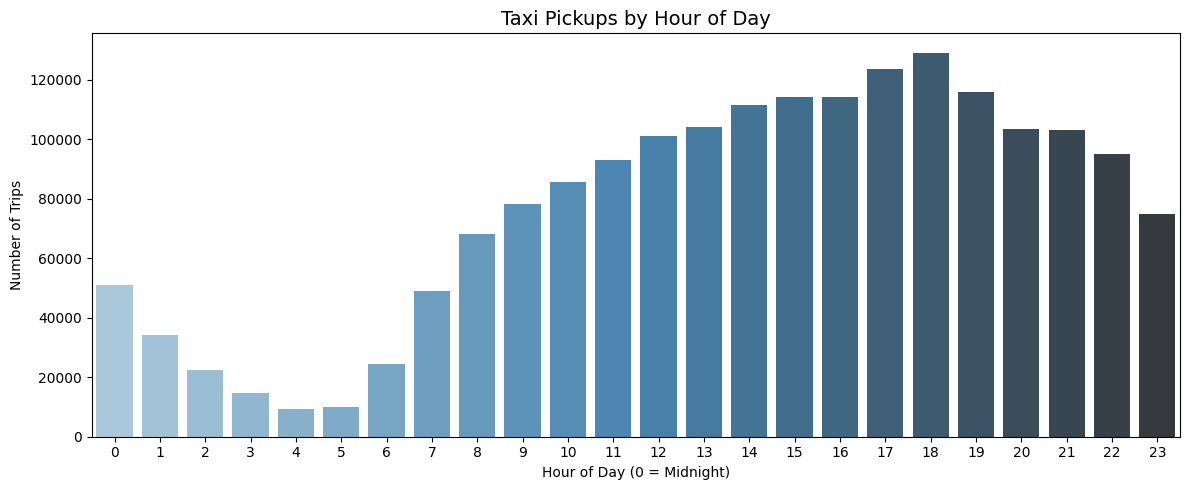

Busiest hour ( 24 hr basis ): 18


In [ ]:
# Find and show the hourly trends in taxi pickups

'''
* VendorID: Categorical
* tpep_pickup_datetime: Datetime (Temporal)
* tpep_dropoff_datetime: Datetime (Temporal)
* passenger_count: Numerical (Discrete)
* trip_distance: Numerical (Continuous)
* RatecodeID: Categorical
* PULocationID: Categorical
* DOLocationID: Categorical
* payment_type: Categorical
* pickup_hour: Numerical (Discrete) — can also be treated as Categorical
* trip_duration: Numerical (Continuous)

The monetary parameters (fare_amount, extra, mta_tax, tip_amount, tolls_amount,
improvement_surcharge, total_amount, congestion_surcharge, airport_fee)
are all Numerical (Continuous).

'''

hourly_counts = df.groupby('pickup_hour').size().reset_index(name='trip_count')

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly_counts, x='pickup_hour', y='trip_count', palette='Blues_d')
plt.title('Taxi Pickups by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

# To know the busiest houer in the week
print("Busiest hour ( 24 hr basis ):", hourly_counts.loc[hourly_counts['trip_count'].idxmax(), 'pickup_hour'])

In [ ]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour'],
      dtype='object')

In [ ]:
df.shape

(1831388, 19)

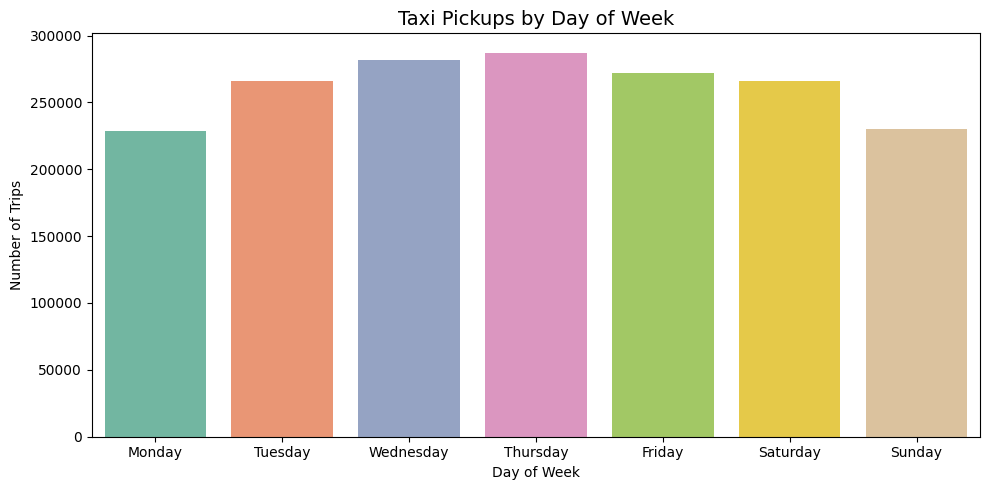

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)

#Converting the tpep_pickup_datetime column to datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_counts = df.groupby('pickup_day').size().reset_index(name='trip_count')

# Used categorical method to order the week days
daily_counts['pickup_day'] = pd.Categorical(daily_counts['pickup_day'], categories=day_order, ordered=True)
daily_counts = daily_counts.sort_values('pickup_day')

# Plotting the curve
plt.figure(figsize=(10, 5))
sns.barplot(data=daily_counts, x='pickup_day', y='trip_count', palette='Set2')
plt.title('Taxi Pickups by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

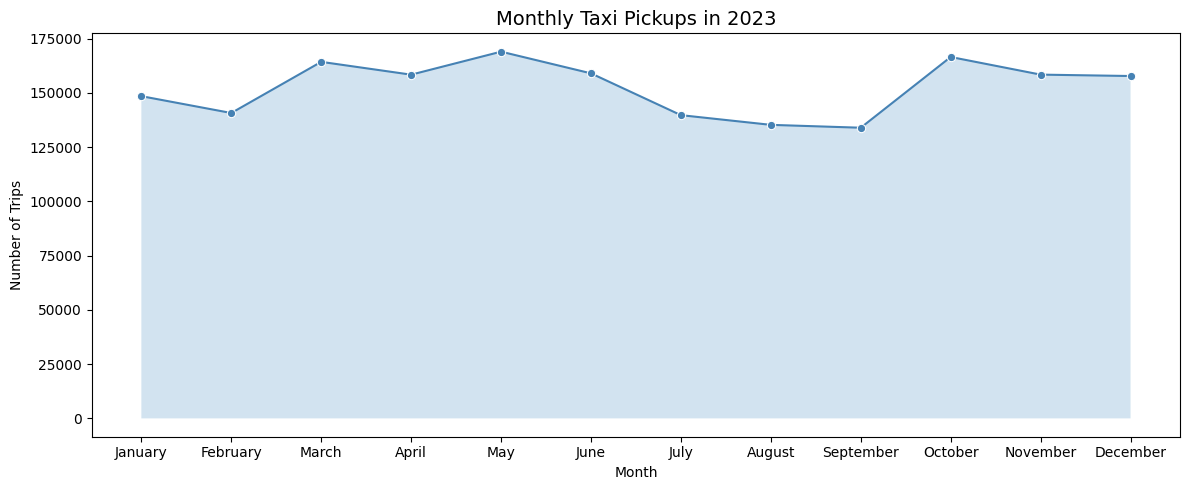

In [ ]:
# Show the monthly trends in pickups

df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.month_name()

month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

# Used categorical method to keep teh data in order
monthly_counts = df.groupby('pickup_month_name').size().reset_index(name='trip_count')
monthly_counts['pickup_month_name'] = pd.Categorical(monthly_counts['pickup_month_name'],
                                                      categories=month_order, ordered=True)
monthly_counts = monthly_counts.sort_values('pickup_month_name')

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_counts, x='pickup_month_name', y='trip_count', marker='o', color='steelblue')
plt.fill_between(range(len(monthly_counts)), monthly_counts['trip_count'], alpha=0.2)
plt.xticks(range(len(monthly_counts)), monthly_counts['pickup_month_name'])
plt.title('Monthly Taxi Pickups in 2023', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters

fin_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
print(df[fin_cols].describe())

# Check for zero values
for col in fin_cols:
    zeros = (df[col] == 0).sum()
    print(f"Zero values in '{col}': {zeros} ({zeros/len(df)*100:.2f}%)")






        fare_amount    tip_amount  total_amount  trip_distance
count  1.831388e+06  1.831388e+06  1.831388e+06   1.831388e+06
mean   1.973805e+01  3.573489e+00  2.886171e+01   3.444843e+00
std    1.825445e+01  4.069044e+00  2.287232e+01   4.545774e+00
min    0.000000e+00  0.000000e+00  0.000000e+00   0.000000e+00
25%    9.300000e+00  1.000000e+00  1.596000e+01   1.050000e+00
50%    1.350000e+01  2.860000e+00  2.100000e+01   1.780000e+00
75%    2.190000e+01  4.450000e+00  3.070000e+01   3.370000e+00
max    1.375000e+03  2.230800e+02  1.435190e+03   2.048600e+02
Zero values in 'fare_amount': 575 (0.03%)
Zero values in 'tip_amount': 410233 (22.40%)
Zero values in 'total_amount': 255 (0.01%)
Zero values in 'trip_distance': 22928 (1.25%)


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected financial parameters.

# I kept trip_distance = 0 only when PULocationID == DOLocationID (same zone)

df = df[
    (df['fare_amount'] > 0) &
    (df['tip_amount'] >= 0) &     # tip can be 0 (cash)
    (df['total_amount'] > 0) &
    (df['trip_distance'] >= 0)    # 0 distance allowed if same zone
].copy()


print(f"Non-zero filtered shape: {df.shape}")



Non-zero filtered shape: (1830813, 21)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

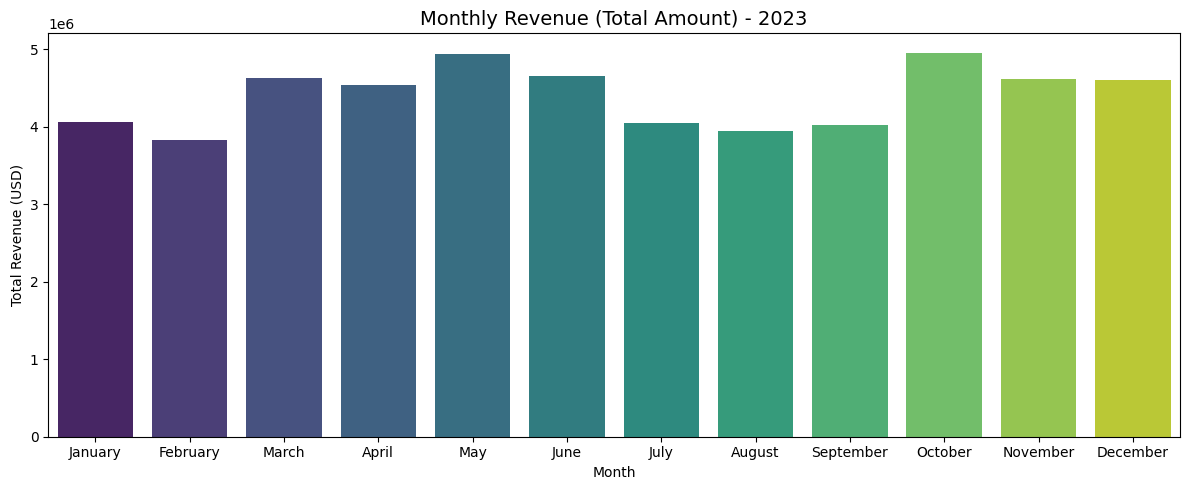

   pickup_month_name  total_amount
4            January    4055029.98
3           February    3834247.87
7              March    4624075.36
0              April    4540572.22
8                May    4944628.60
6               June    4654431.12
5               July    4051014.88
1             August    3948413.39
11         September    4028474.19
10           October    4957127.81
9           November    4614342.26
2           December    4602738.11


In [ ]:
# Group data by month and analyse monthly revenue

month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

# Used categorial method to keep the month_data in order
monthly_revenue = df.groupby('pickup_month_name')['total_amount'].sum().reset_index()
monthly_revenue['pickup_month_name'] = pd.Categorical(monthly_revenue['pickup_month_name'],
                                                        categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values('pickup_month_name')

# Plotting the curve
plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_revenue, x='pickup_month_name', y='total_amount', palette='viridis')
plt.title('Monthly Revenue (Total Amount) - 2023', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

print(monthly_revenue)



**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

Quarterly Revenue Share:
pickup_quarter
1    23.67
2    26.75
3    22.76
4    26.82
Name: total_amount, dtype: float64


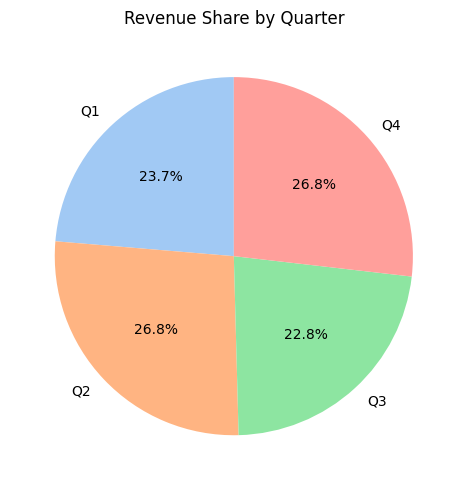

In [ ]:
# Calculate proportion of each quarter

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()
quarterly_pct = (quarterly_revenue / quarterly_revenue.sum() * 100).round(2)

print("Quarterly Revenue Share:")
print(quarterly_pct)

plt.figure(figsize=(14,5))

plt.pie(
    quarterly_revenue,
    labels=[f'Q{q}' for q in quarterly_revenue.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

plt.title('Revenue Share by Quarter')

plt.tight_layout()
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [ ]:
df.shape

(1830813, 22)

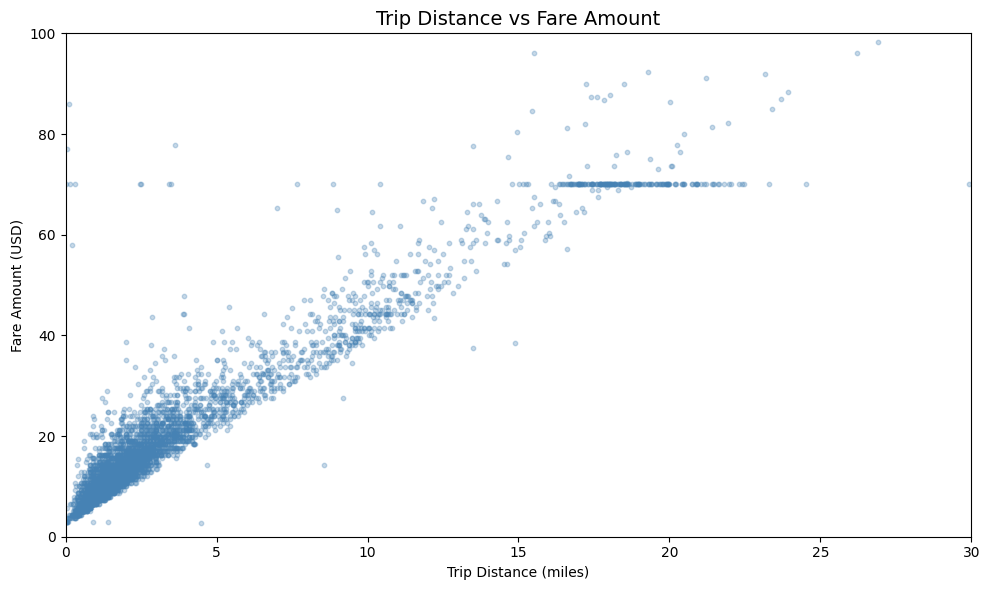

Pearson Correlation (trip_distance vs fare_amount): 0.9517


In [ ]:
# Show how trip fare is affected by distance
df_dist = df[df['trip_distance'] > 0].copy()

# Sample for plotting to avoid overplotting
plot_sample = df_dist.sample(n=min(5000, len(df_dist)), random_state=42)

# Plotting the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_sample['trip_distance'], plot_sample['fare_amount'],
           alpha=0.3, s=10, color='steelblue')

# The limits are set to keep away outliers
ax.set_xlim(0, 30)
ax.set_ylim(0, 100)

ax.set_title('Trip Distance vs Fare Amount', fontsize=14)
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Fare Amount (USD)')
plt.tight_layout()
plt.show()

# To keep out outliers
df_clean = df_dist[
    (df_dist['trip_distance'] <= 30) &
    (df_dist['fare_amount'] <= 100)
].copy()

correlation = df_clean['trip_distance'].corr(df_clean['fare_amount'])
print(f"Pearson Correlation (trip_distance vs fare_amount): {correlation:.4f}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [ ]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour', 'pickup_day',
       'pickup_month_name', 'pickup_quarter'],
      dtype='object')

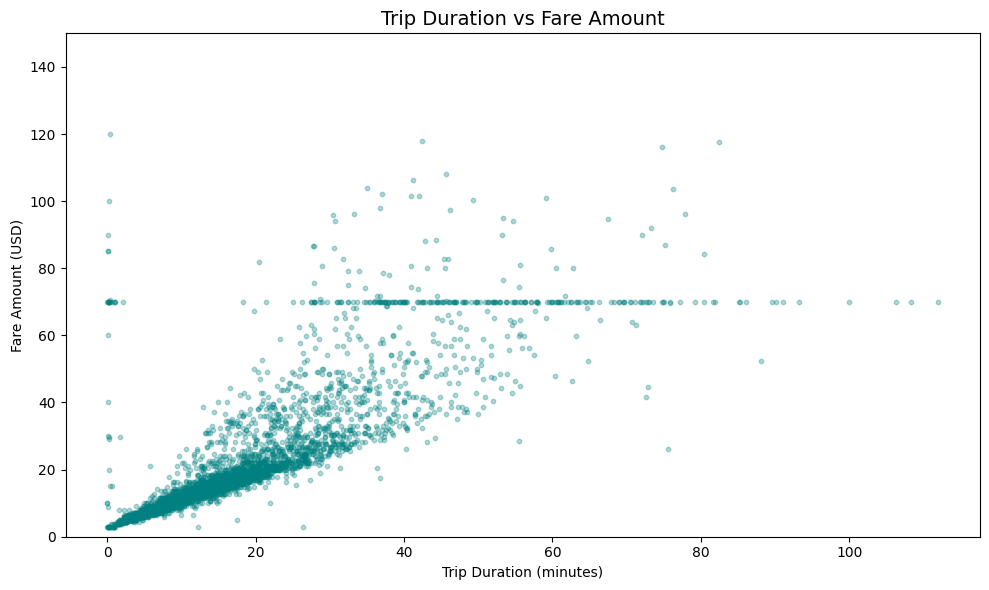

Correlation (trip_duration vs fare_amount): 0.8800


In [ ]:
# Show relationship between fare and trip duration

# Converting to datetime format
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Defining trip duration
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

plot_sample = df[df['trip_duration'] <= 120].sample(n=min(5000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_sample['trip_duration'], plot_sample['fare_amount'],
           alpha=0.3, s=10, color='teal')
ax.set_title('Trip Duration vs Fare Amount', fontsize=14)
ax.set_xlabel('Trip Duration (minutes)')
ax.set_ylabel('Fare Amount (USD)')
ax.set_ylim(0, 150)
plt.tight_layout()
plt.show()

'''  A filter is added here, since correlation comes nearly 0.27 when we pass the df data.
It is becuase of horzontal line with fare amount 70 and there are abnormally high fare amount
for less duration, so took <90
'''

filtered = df[
    (df['fare_amount'] < 70) &
    (df['trip_duration'] < 90)
]

corr_dur_fare = filtered['trip_duration'].corr(filtered['fare_amount'])
print(f"Correlation (trip_duration vs fare_amount): {corr_dur_fare:.4f}")

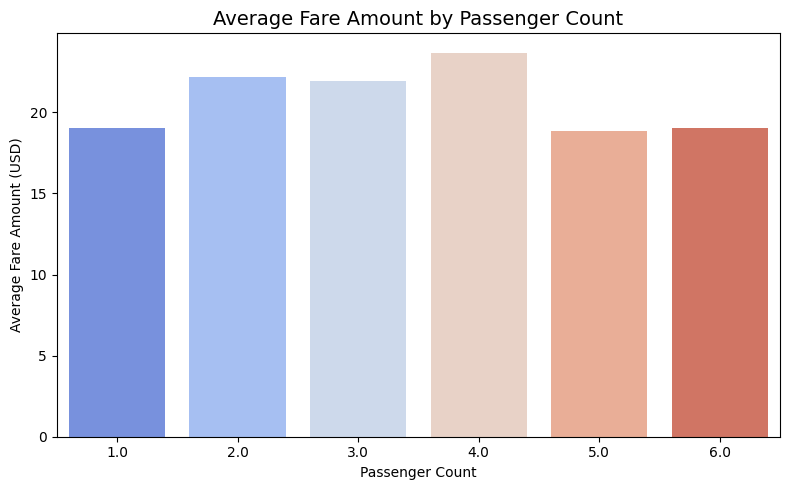

Correlation (passenger_count vs fare_amount): 0.0443


In [ ]:
# Show relationship between fare and number of passengers

avg_fare_by_pax = df.groupby('passenger_count')['fare_amount'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=avg_fare_by_pax, x='passenger_count', y='fare_amount', palette='coolwarm', ax=ax)
ax.set_title('Average Fare Amount by Passenger Count', fontsize=14)
ax.set_xlabel('Passenger Count')
ax.set_ylabel('Average Fare Amount (USD)')
plt.tight_layout()
plt.show()

corr_pax_fare = df['passenger_count'].corr(df['fare_amount'])
print(f"Correlation (passenger_count vs fare_amount): {corr_pax_fare:.4f}")



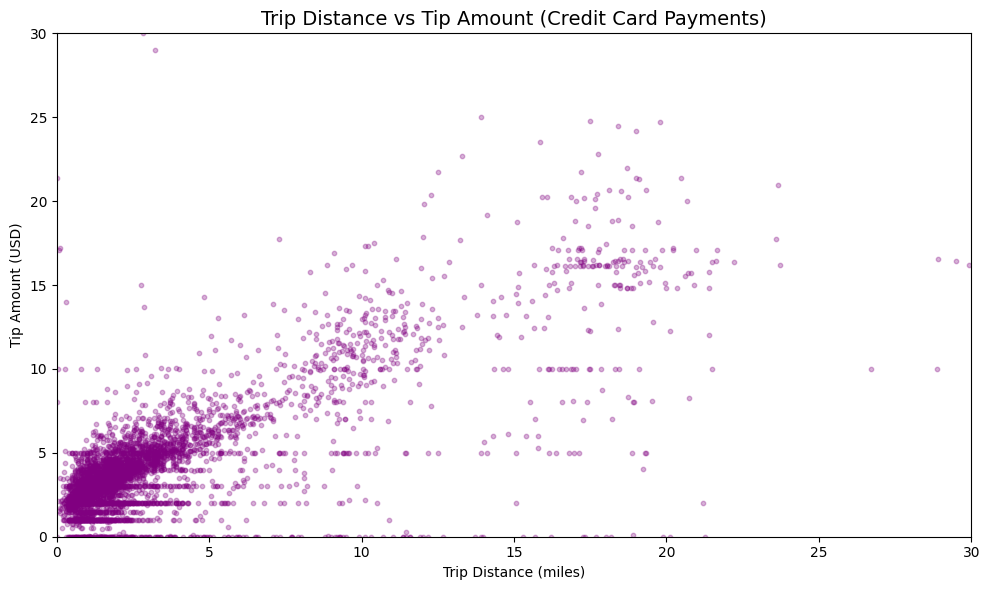

Correlation (trip_distance vs tip_amount): 0.7295


In [ ]:
# Show relationship between tip and trip distance


df_tip = df[(df['trip_distance'] > 0) & (df['payment_type'] == 1)].copy()
plot_sample = df_tip.sample(n=min(5000, len(df_tip)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_sample['trip_distance'], plot_sample['tip_amount'],
           alpha=0.3, s=10, color='purple')
ax.set_xlim(0, 30)
ax.set_ylim(0, 30)
ax.set_title('Trip Distance vs Tip Amount (Credit Card Payments)', fontsize=14)
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Tip Amount (USD)')
plt.tight_layout()
plt.show()

corr_dist_tip = df_tip['trip_distance'].corr(df_tip['tip_amount'])
print(f"Correlation (trip_distance vs tip_amount): {corr_dist_tip:.4f}")



**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

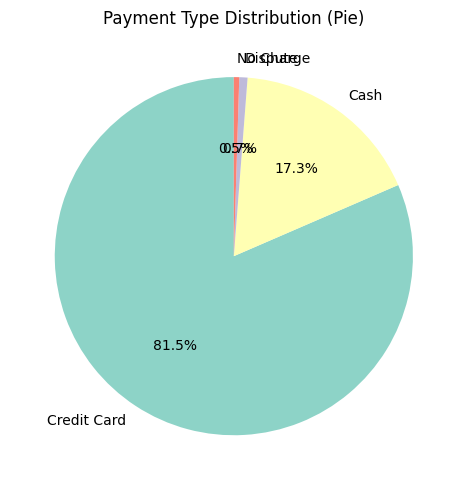

payment_type
Credit Card    1492179
Cash            316182
Dispute          13567
No Charge         8885
Name: count, dtype: int64


In [ ]:
# Analyse the distribution of different payment types (payment_type).

payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
payment_counts = df['payment_type'].map(payment_map).value_counts()

fig, axes = plt.subplots(1, 1, figsize=(14, 5))

axes.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3'), startangle=90)
axes.set_title('Payment Type Distribution (Pie)')

plt.tight_layout()
plt.show()
print(payment_counts)


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
 !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file('data/taxi_zones.shp')

# Display the GeoDataFrame
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


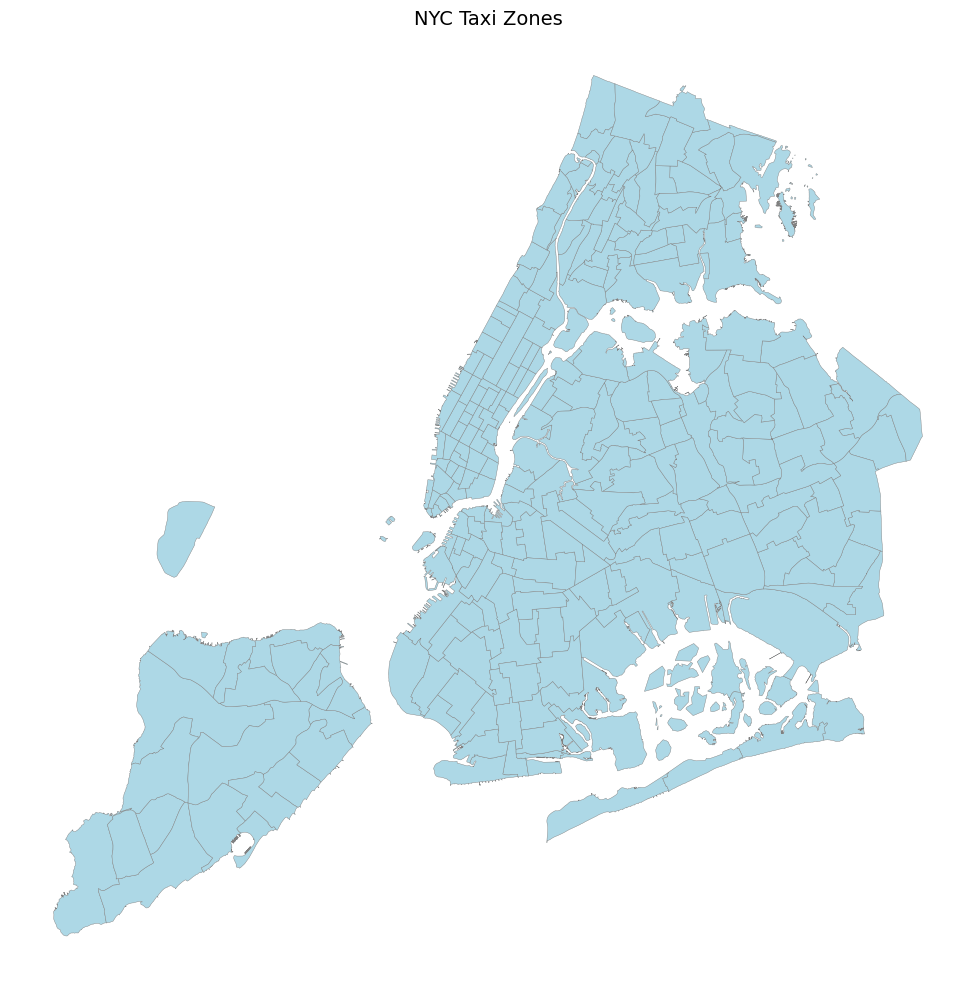

In [ ]:
print(zones.info())
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zones.plot(ax=ax, color='lightblue', edgecolor='gray', linewidth=0.3)
ax.set_title('NYC Taxi Zones', fontsize=14)

# Since we dont want unwanted data in plot, ax.axis is off
ax.axis('off')

plt.tight_layout()
plt.show()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour', 'pickup_day',
       'pickup_month_name', 'pickup_quarter', 'trip_duration'],
      dtype='object')

In [ ]:
df.shape

(1830813, 23)

In [ ]:
# Merge zones and trip records using locationID and PULocationID

# Zone geometry, shapes, metadata and other columns are not required
# Only three columns are required LocationID, zone and borough
df_merged = df.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

df_merged.rename(columns={'zone': 'pickup_zone', 'borough': 'pickup_borough'}, inplace=True)
df_merged.drop(columns=['LocationID'], inplace=True)
print("Merged shape:", df_merged.shape)
df_merged[['PULocationID', 'pickup_zone', 'pickup_borough']].head()



Merged shape: (1830937, 25)


,PULocationID,pickup_zone,pickup_borough
0,138,LaGuardia Airport,Queens
1,161,Midtown Center,Manhattan
2,237,Upper East Side South,Manhattan
3,143,Lincoln Square West,Manhattan
4,246,West Chelsea/Hudson Yards,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips

trip_counts = df_merged.groupby('PULocationID').size().reset_index(name='num_trips')
print("Top 10 zones by number of trips:")
print(trip_counts.sort_values('num_trips', ascending=False).head(10))

Top 10 zones by number of trips:
     PULocationID  num_trips
125           132      96755
229           237      86895
154           161      85930
228           236      77507
155           162      65629
131           138      64156
178           186      63464
222           230      61305
135           142      60878
163           170      54481


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame

zones_with_trips = zones.merge(trip_counts, left_on='LocationID', right_on='PULocationID', how='left')
zones_with_trips['num_trips'] = zones_with_trips['num_trips'].fillna(0)
print("zones_with_trips shape:", zones_with_trips.shape)
zones_with_trips[['LocationID', 'zone', 'borough', 'num_trips']]




zones_with_trips shape: (263, 9)


,LocationID,zone,borough,num_trips
0,1,Newark Airport,EWR,213.0
1,2,Jamaica Bay,Queens,2.0
2,3,Allerton/Pelham Gardens,Bronx,40.0
3,4,Alphabet City,Manhattan,1861.0
4,5,Arden Heights,Staten Island,13.0
...,...,...,...,...
258,259,Woodlawn/Wakefield,Bronx,47.0
259,260,Woodside,Queens,357.0
260,261,World Trade Center,Manhattan,9604.0
261,262,Yorkville East,Manhattan,23616.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

In [ ]:
print(type(zones_with_trips))

<class 'geopandas.geodataframe.GeoDataFrame'>


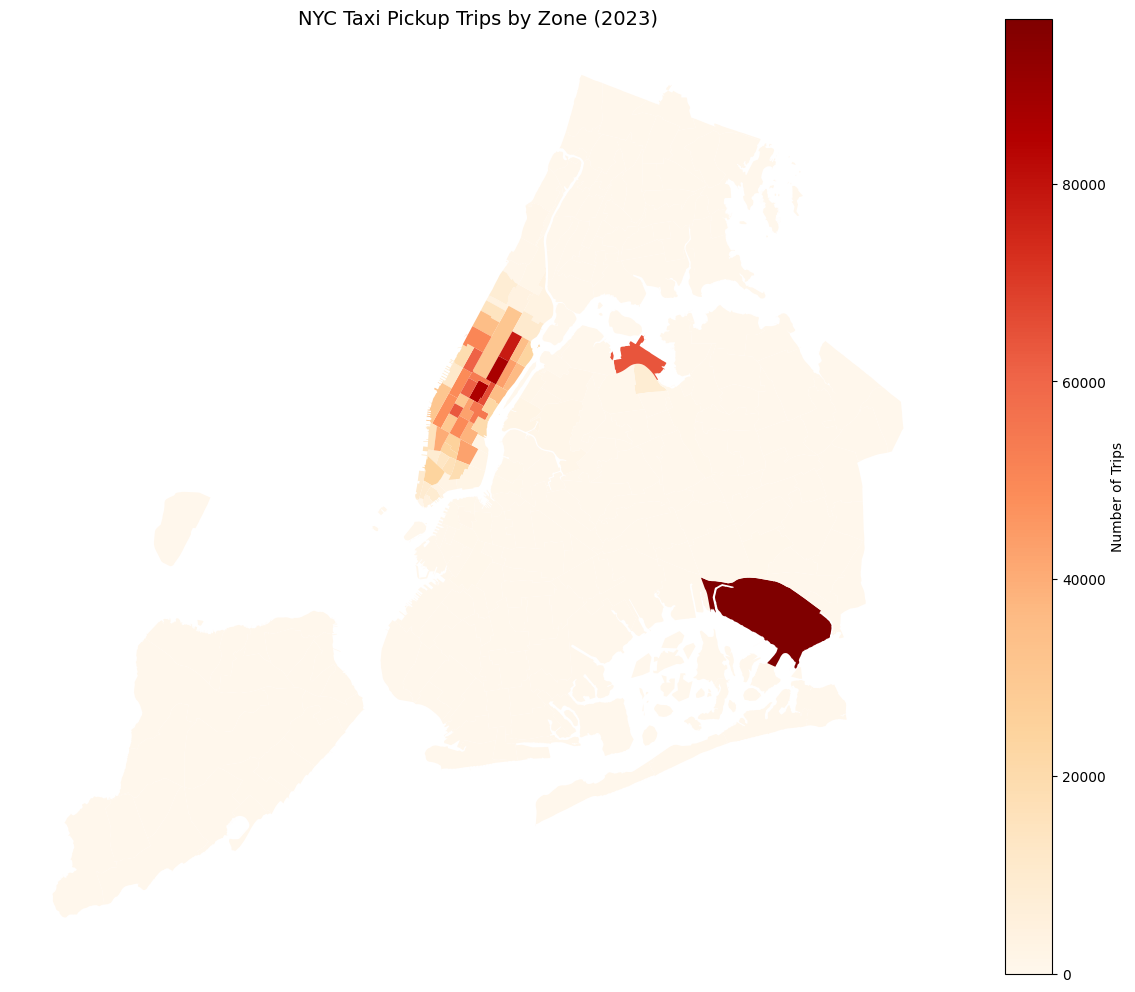

In [ ]:
# Define figure and axis

plt.close('all')

# Plot the map and display it
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the choropleth map

zones_with_trips.plot(
    column='num_trips',
    ax=ax,
    legend=True,
    cmap='OrRd',
    legend_kwds={'label': "Number of Trips", 'orientation': "vertical"},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax.set_title('NYC Taxi Pickup Trips by Zone (2023)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
# can you try displaying the zones DF sorted by the number of trips?

zones_with_trips[['zone', 'borough', 'num_trips']].sort_values('num_trips', ascending=False).head(20)



,zone,borough,num_trips
131,JFK Airport,Queens,96755.0
236,Upper East Side South,Manhattan,86895.0
160,Midtown Center,Manhattan,85930.0
235,Upper East Side North,Manhattan,77507.0
161,Midtown East,Manhattan,65629.0
137,LaGuardia Airport,Queens,64156.0
185,Penn Station/Madison Sq West,Manhattan,63464.0
229,Times Sq/Theatre District,Manhattan,61305.0
141,Lincoln Square East,Manhattan,60878.0
169,Murray Hill,Manhattan,54481.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day

df_routes = df[(df['trip_distance'] > 0) & (df['trip_duration'] > 0)].copy()

# Speed = distance / (duration in hours)
df_routes['speed_mph'] = df_routes['trip_distance'] / (df_routes['trip_duration'] / 60)
df_routes['route'] = df_routes['PULocationID'].astype(str) + '_' + df_routes['DOLocationID'].astype(str)

# Average speed per route per hour
route_speed = df_routes.groupby(['route', 'pickup_hour'])['speed_mph'].mean().reset_index()
route_speed = route_speed.sort_values('speed_mph')

print("Top 10 slowest routes by hour:")
print(route_speed.head(10))



Top 10 slowest routes by hour:
          route  pickup_hour  speed_mph
72181    232_65           13   0.005324
84121   243_264           17   0.007772
29473   142_142            5   0.023770
90520   258_258            1   0.026230
1947      100_7            8   0.039470
99037     40_65           21   0.046848
5992    113_235           22   0.048105
58291   194_194           16   0.048913
102939    45_45           10   0.059484
96678   264_168           23   0.071573


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

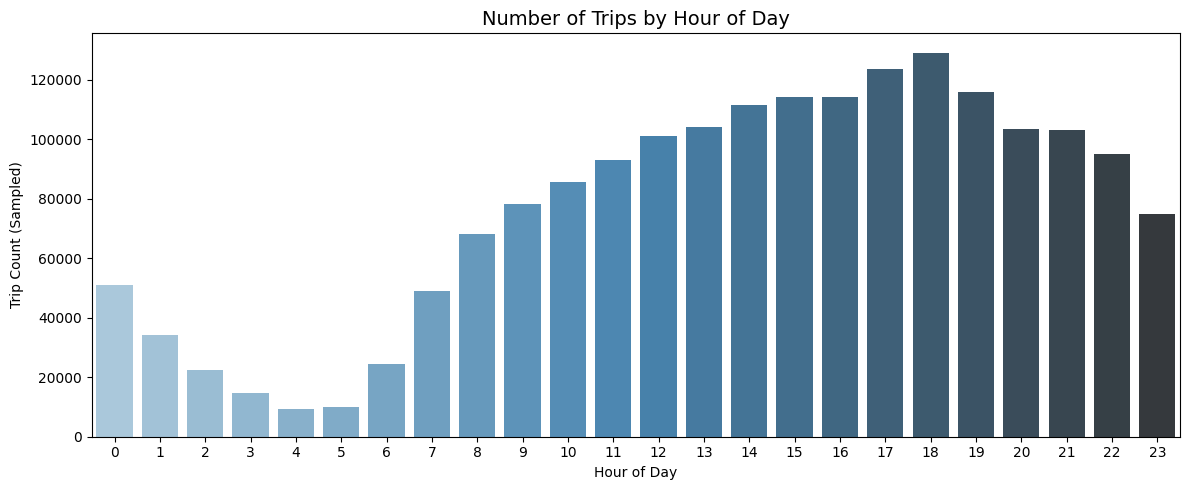

Busiest hour: 18:00
    pickup_hour  trip_count
18           18      129156
17           17      123527
19           19      115879
15           15      114262
16           16      114251


In [ ]:
# Visualise the number of trips per hour and find the busiest hour

hourly_trips = df.groupby('pickup_hour').size().reset_index(name='trip_count')

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly_trips, x='pickup_hour', y='trip_count', palette='Blues_d')
plt.title('Number of Trips by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Trip Count (Sampled)')
plt.tight_layout()
plt.show()

busiest_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmax(), 'pickup_hour']
print(f"Busiest hour: {busiest_hour}:00")
print(hourly_trips.sort_values('trip_count', ascending=False).head(5))



Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips
# Fill in the value of your sampling fraction
sample_fraction = 0.05

# Top 5 busiest hours (sampled counts)
top_5 = hourly_trips.sort_values('trip_count', ascending=False).head(5).copy()

# Scale up by the inverse of the sampling fraction
top_5['estimated_actual_trips'] = (top_5['trip_count'] / sample_fraction).astype(int)
print("Top 5 Busiest Hours - Estimated Actual Trips:")
print(top_5[['pickup_hour', 'trip_count', 'estimated_actual_trips']])


Top 5 Busiest Hours - Estimated Actual Trips:
    pickup_hour  trip_count  estimated_actual_trips
18           18      129156                 2583120
17           17      123527                 2470540
19           19      115879                 2317580
15           15      114262                 2285240
16           16      114251                 2285020


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

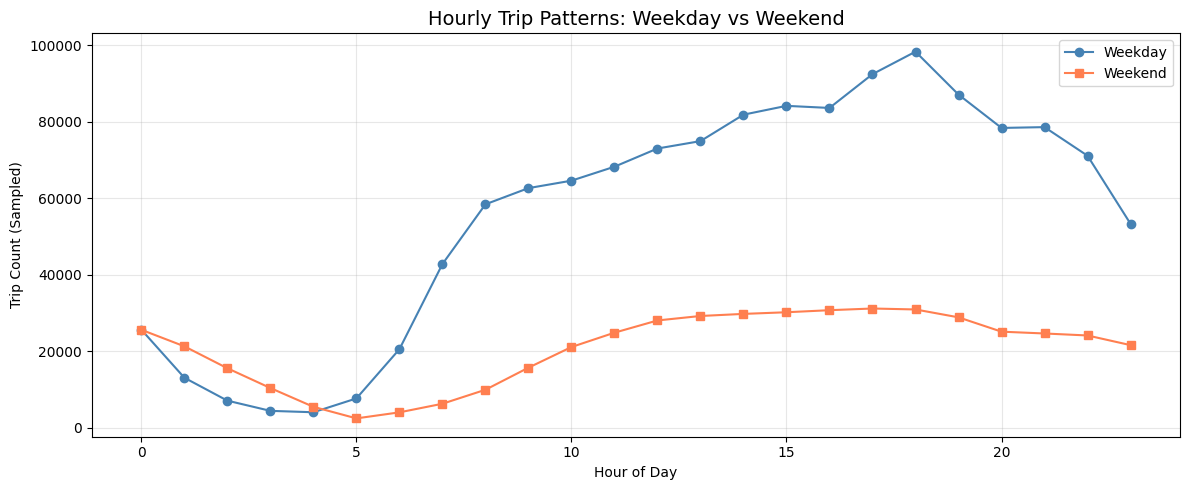

In [ ]:
# Compare traffic trends for the week days and weekends

# Compare traffic trends for weekdays and weekends

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['is_weekend'] = df['pickup_day'].isin(['Saturday', 'Sunday'])

hourly_weekday = df[~df['is_weekend']].groupby('pickup_hour').size().reset_index(name='trip_count')
hourly_weekend = df[df['is_weekend']].groupby('pickup_hour').size().reset_index(name='trip_count')

plt.figure(figsize=(12, 5))
plt.plot(hourly_weekday['pickup_hour'], hourly_weekday['trip_count'], marker='o', label='Weekday', color='steelblue')
plt.plot(hourly_weekend['pickup_hour'], hourly_weekend['trip_count'], marker='s', label='Weekend', color='coral')
plt.title('Hourly Trip Patterns: Weekday vs Weekend', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Trip Count (Sampled)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour', 'pickup_day',
       'pickup_month_name', 'pickup_quarter', 'trip_duration', 'is_weekend'],
      dtype='object')

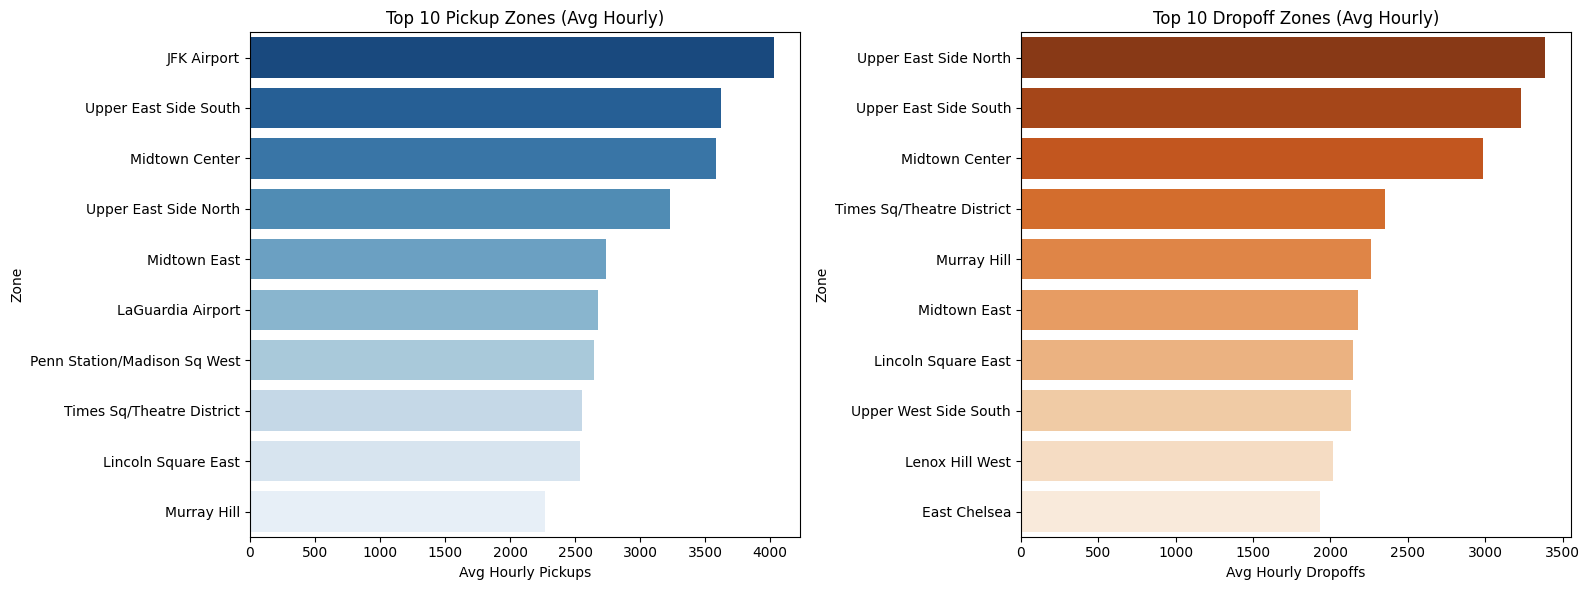

In [ ]:
# Find top 10 pickup and dropoff zones

top_pu = df.groupby('PULocationID').size().div(df['pickup_hour'].nunique()).reset_index(name='avg_hourly_pickups')
top_pu = top_pu.sort_values('avg_hourly_pickups', ascending=False).head(10)

top_do = df.groupby('DOLocationID').size().div(df['pickup_hour'].nunique()).reset_index(name='avg_hourly_dropoffs')
top_do = top_do.sort_values('avg_hourly_dropoffs', ascending=False).head(10)

# Merge with zone names
top_pu = top_pu.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')
top_do = top_do.merge(zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_pu, y='zone', x='avg_hourly_pickups', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Pickup Zones (Avg Hourly)', fontsize=12)
axes[0].set_xlabel('Avg Hourly Pickups')
axes[0].set_ylabel('Zone')

sns.barplot(data=top_do, y='zone', x='avg_hourly_dropoffs', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 10 Dropoff Zones (Avg Hourly)', fontsize=12)
axes[1].set_xlabel('Avg Hourly Dropoffs')
axes[1].set_ylabel('Zone')

plt.tight_layout()
plt.show()



**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pu_counts = df.groupby('PULocationID').size().reset_index(name='pickups')
do_counts = df.groupby('DOLocationID').size().reset_index(name='dropoffs')

ratio_df = pu_counts.merge(do_counts, left_on='PULocationID', right_on='DOLocationID', how='inner')
ratio_df['pu_do_ratio'] = ratio_df['pickups'] / ratio_df['dropoffs']
ratio_df = ratio_df.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')

print("Top 10 zones (highest pickup/dropoff ratio - more pickups than dropoffs):")
print(ratio_df.nlargest(10, 'pu_do_ratio')[['zone', 'pickups', 'dropoffs', 'pu_do_ratio']])

print("\nBottom 10 zones (lowest pickup/dropoff ratio - more dropoffs than pickups):")
print(ratio_df.nsmallest(10, 'pu_do_ratio')[['zone', 'pickups', 'dropoffs', 'pu_do_ratio']])



Top 10 zones (highest pickup/dropoff ratio - more pickups than dropoffs):
                             zone  pickups  dropoffs  pu_do_ratio
69                  East Elmhurst     8342       990     8.426263
126                   JFK Airport    96755     20914     4.626327
132             LaGuardia Airport    64156     22238     2.884972
179  Penn Station/Madison Sq West    63464     40105     1.582446
108       Greenwich Village South    24111     17536     1.374943
41                   Central Park    30748     22365     1.374827
240                  West Village    40399     30462     1.326210
156                  Midtown East    65629     52242     1.256250
155                Midtown Center    85930     71636     1.199537
98               Garment District    30203     25341     1.191863

Bottom 10 zones (lowest pickup/dropoff ratio - more dropoffs than pickups):
                                    zone  pickups  dropoffs  pu_do_ratio
26   Breezy Point/Fort Tilden/Riis Beach        1 

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

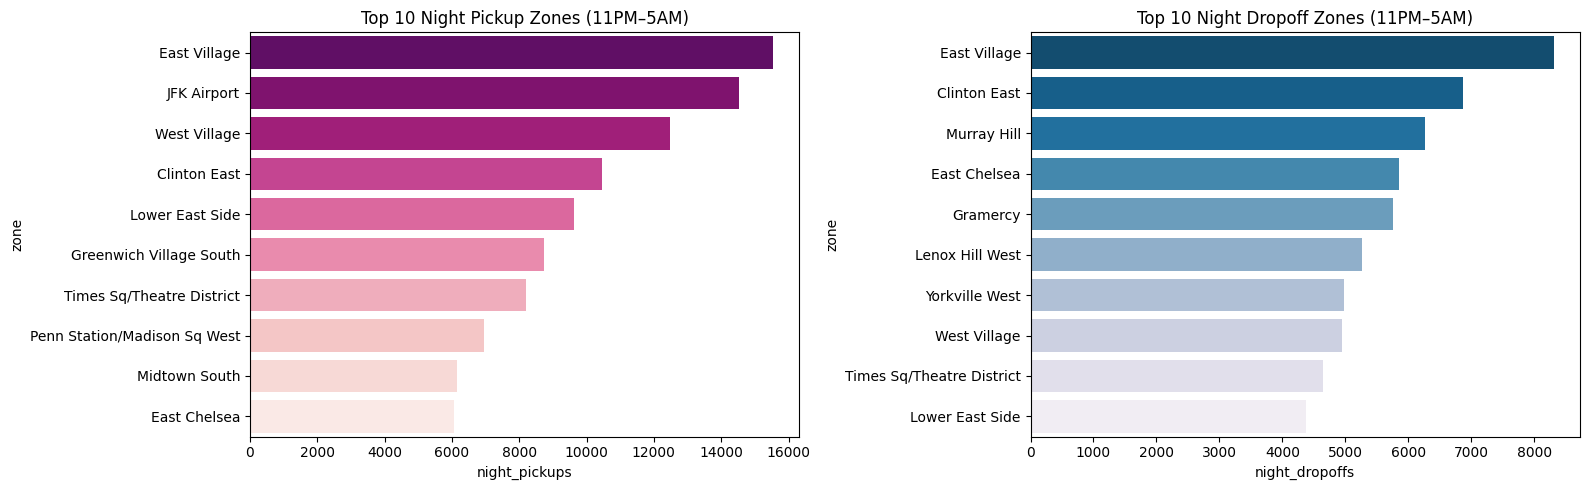

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_df = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)].copy()

night_pu = night_df.groupby('PULocationID').size().reset_index(name='night_pickups')
night_do = night_df.groupby('DOLocationID').size().reset_index(name='night_dropoffs')
night_pu = night_pu.sort_values('night_pickups', ascending=False).head(10)
night_do = night_do.sort_values('night_dropoffs', ascending=False).head(10)

night_pu = night_pu.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')
night_do = night_do.merge(zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=night_pu, y='zone', x='night_pickups', palette='RdPu_r', ax=axes[0])
axes[0].set_title('Top 10 Night Pickup Zones (11PM–5AM)', fontsize=12)

sns.barplot(data=night_do, y='zone', x='night_dropoffs', palette='PuBu_r', ax=axes[1])
axes[1].set_title('Top 10 Night Dropoff Zones (11PM–5AM)', fontsize=12)
plt.tight_layout()
plt.show()




Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Night Revenue  (11PM-5AM): $6,393,748.41 (12.1%)
Day Revenue    (5AM-11PM): $46,461,347.38 (87.9%)


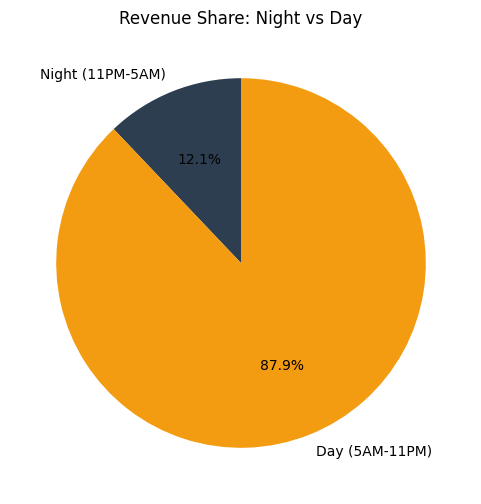

In [ ]:
# Filter for night hours (11 PM to 5 AM)

night_rev = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)]['total_amount'].sum()
day_rev = df[(df['pickup_hour'] > 5) & (df['pickup_hour'] < 23)]['total_amount'].sum()
total_rev = night_rev + day_rev

print(f"Night Revenue  (11PM-5AM): ${night_rev:,.2f} ({night_rev/total_rev*100:.1f}%)")
print(f"Day Revenue    (5AM-11PM): ${day_rev:,.2f} ({day_rev/total_rev*100:.1f}%)")

plt.figure(figsize=(6, 6))
plt.pie([night_rev, day_rev], labels=['Night (11PM-5AM)', 'Day (5AM-11PM)'],
        autopct='%1.1f%%', colors=['#2c3e50', '#f39c12'], startangle=90)
plt.title('Revenue Share: Night vs Day')
plt.show()



##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
df.shape

(1830813, 24)

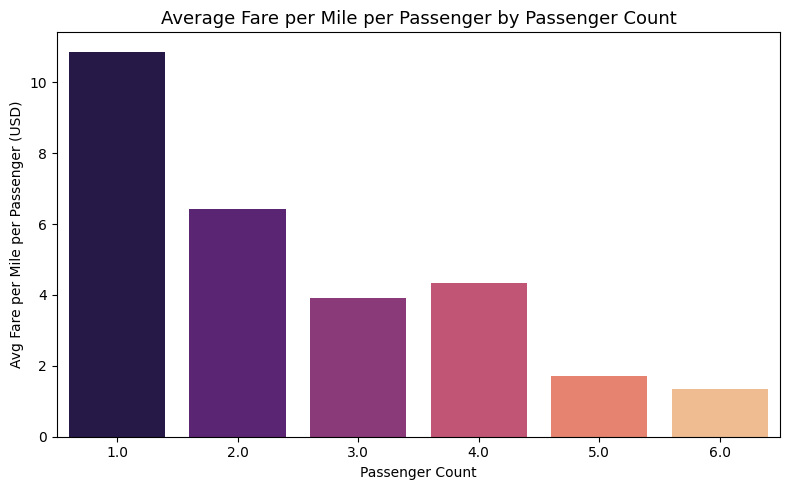

   passenger_count  fare_per_mile_per_pax
0              1.0              10.864665
1              2.0               6.432401
2              3.0               3.908099
3              4.0               4.348327
4              5.0               1.709614
5              6.0               1.350744


In [ ]:
# Analyse the fare per mile per passenger for different passenger counts

df_fpm = df[df['trip_distance'] > 0].copy()
df_fpm['fare_per_mile'] = df_fpm['fare_amount'] / df_fpm['trip_distance']
df_fpm['fare_per_mile_per_pax'] = df_fpm['fare_per_mile'] / df_fpm['passenger_count']

avg_fpm_pax = df_fpm.groupby('passenger_count')['fare_per_mile_per_pax'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_fpm_pax, x='passenger_count', y='fare_per_mile_per_pax', palette='magma')
plt.title('Average Fare per Mile per Passenger by Passenger Count', fontsize=13)
plt.xlabel('Passenger Count')
plt.ylabel('Avg Fare per Mile per Passenger (USD)')
plt.tight_layout()
plt.show()
print(avg_fpm_pax)



**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

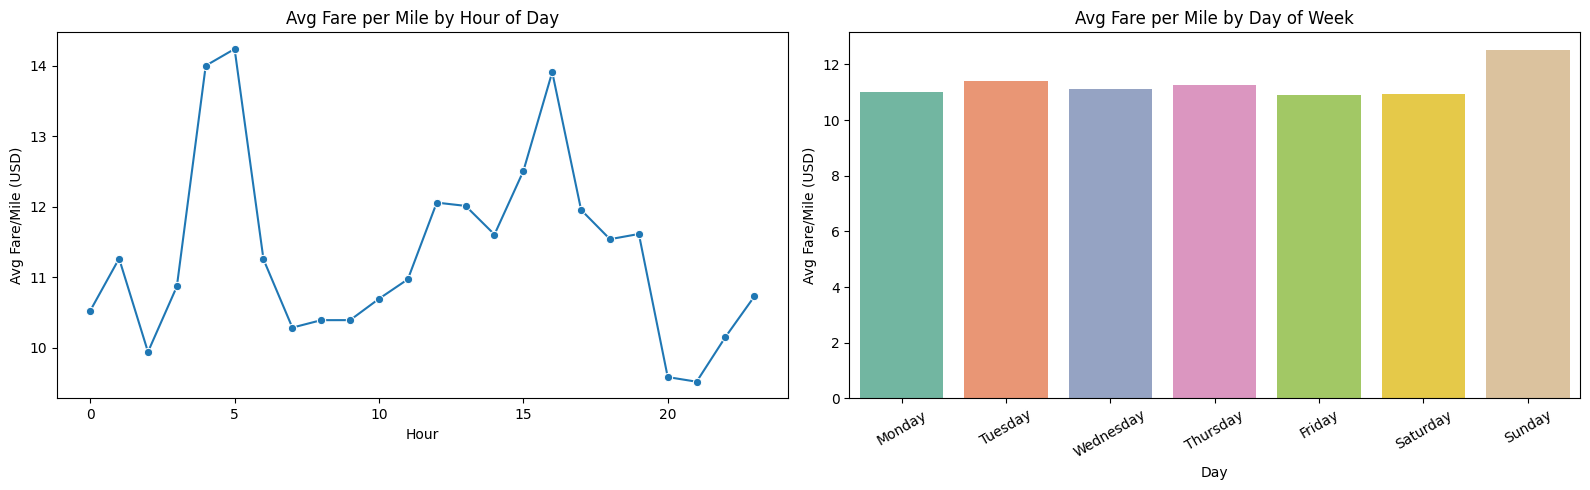

In [ ]:
# Compare the average fare per mile for different days and for different times of the day

import matplotlib.ticker as ticker

df_fpm = df[df['trip_distance'] > 0].copy()
df_fpm['fare_per_mile'] = df_fpm['fare_amount'] / df_fpm['trip_distance']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_fpm = df_fpm.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()
sns.lineplot(data=hourly_fpm, x='pickup_hour', y='fare_per_mile', marker='o', ax=axes[0])
axes[0].set_title('Avg Fare per Mile by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Fare/Mile (USD)')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_fpm = df_fpm.groupby('pickup_day')['fare_per_mile'].mean().reset_index()
daily_fpm['pickup_day'] = pd.Categorical(daily_fpm['pickup_day'], categories=day_order, ordered=True)
daily_fpm = daily_fpm.sort_values('pickup_day')


sns.barplot(data=daily_fpm, x='pickup_day', y='fare_per_mile', palette='Set2', ax=axes[1])
axes[1].set_title('Avg Fare per Mile by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Fare/Mile (USD)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
df.shape

(1830813, 24)

In [ ]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour', 'pickup_day',
       'pickup_month_name', 'pickup_quarter', 'trip_duration', 'is_weekend'],
      dtype='object')

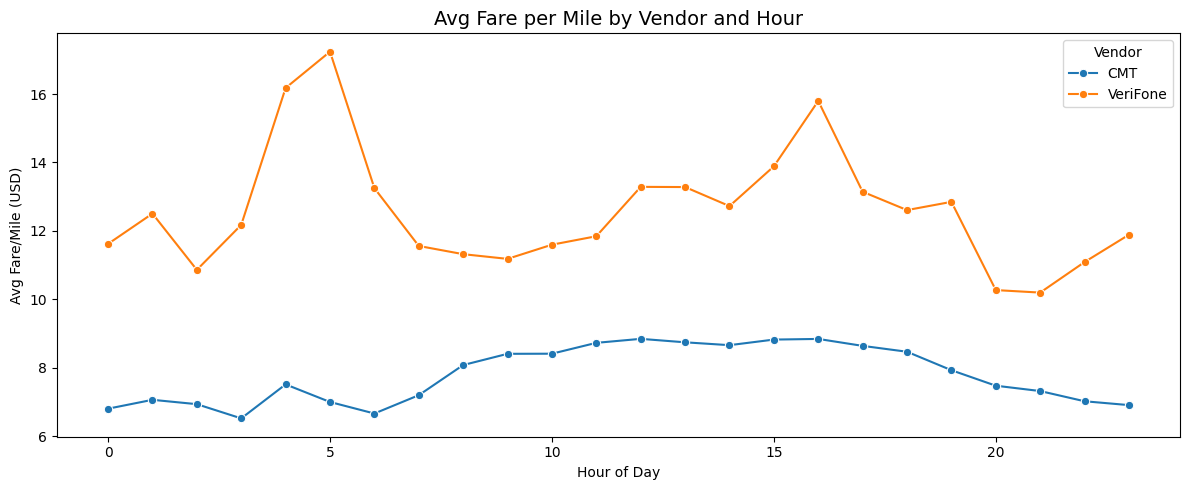

In [ ]:
# Compare fare per mile for different vendors

df_fpm = df[df['trip_distance'] > 0].copy()
df_fpm['fare_per_mile'] = df_fpm['fare_amount'] / df_fpm['trip_distance']
df_fpm['vendor'] = df_fpm['VendorID'].map({1: 'CMT', 2: 'VeriFone'})

vendor_hour_fpm = df_fpm.groupby(['pickup_hour', 'vendor'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=vendor_hour_fpm, x='pickup_hour', y='fare_per_mile', hue='vendor', marker='o')
plt.title('Avg Fare per Mile by Vendor and Hour', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Avg Fare/Mile (USD)')
plt.legend(title='Vendor')
plt.tight_layout()
plt.show()



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


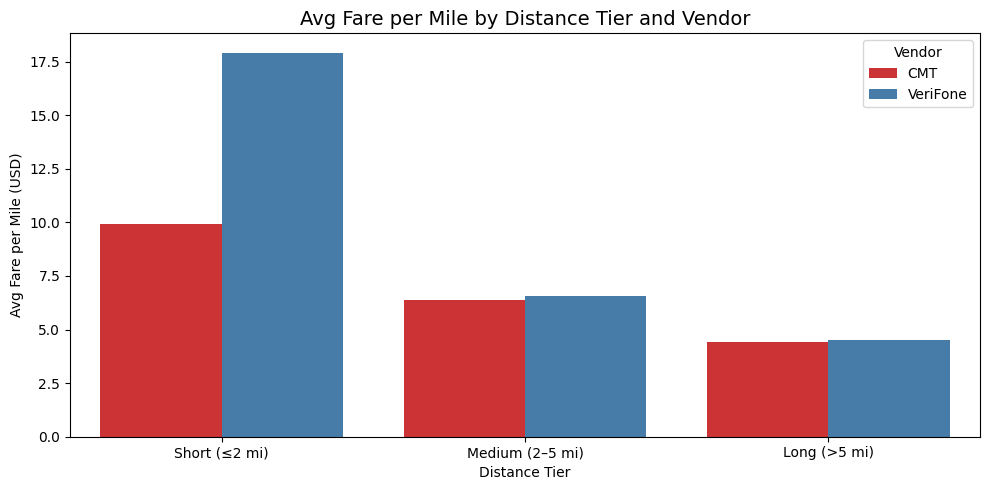

     distance_tier    vendor  fare_per_mile
0    Short (≤2 mi)       CMT       9.926976
1    Short (≤2 mi)  VeriFone      17.926323
2  Medium (2–5 mi)       CMT       6.381262
3  Medium (2–5 mi)  VeriFone       6.549258
4     Long (>5 mi)       CMT       4.425249
5     Long (>5 mi)  VeriFone       4.503240


In [ ]:
# Defining distance tiers

df_tiers = df[df['trip_distance'] > 0].copy()
df_tiers['fare_per_mile'] = df_tiers['fare_amount'] / df_tiers['trip_distance']
df_tiers['vendor'] = df_tiers['VendorID'].map({1: 'CMT', 2: 'VeriFone'})

# Tier 1: up to 2 miles; Tier 2: 2-5 miles; Tier 3: > 5 miles
df_tiers['distance_tier'] = pd.cut(
    df_tiers['trip_distance'],
    bins=[0, 2, 5, np.inf],
    labels=['Short (≤2 mi)', 'Medium (2–5 mi)', 'Long (>5 mi)']
)

tier_vendor = df_tiers.groupby(['distance_tier', 'vendor'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=tier_vendor, x='distance_tier', y='fare_per_mile', hue='vendor', palette='Set1')
plt.title('Avg Fare per Mile by Distance Tier and Vendor', fontsize=14)
plt.xlabel('Distance Tier')
plt.ylabel('Avg Fare per Mile (USD)')
plt.legend(title='Vendor')
plt.tight_layout()
plt.show()

print(tier_vendor)




##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

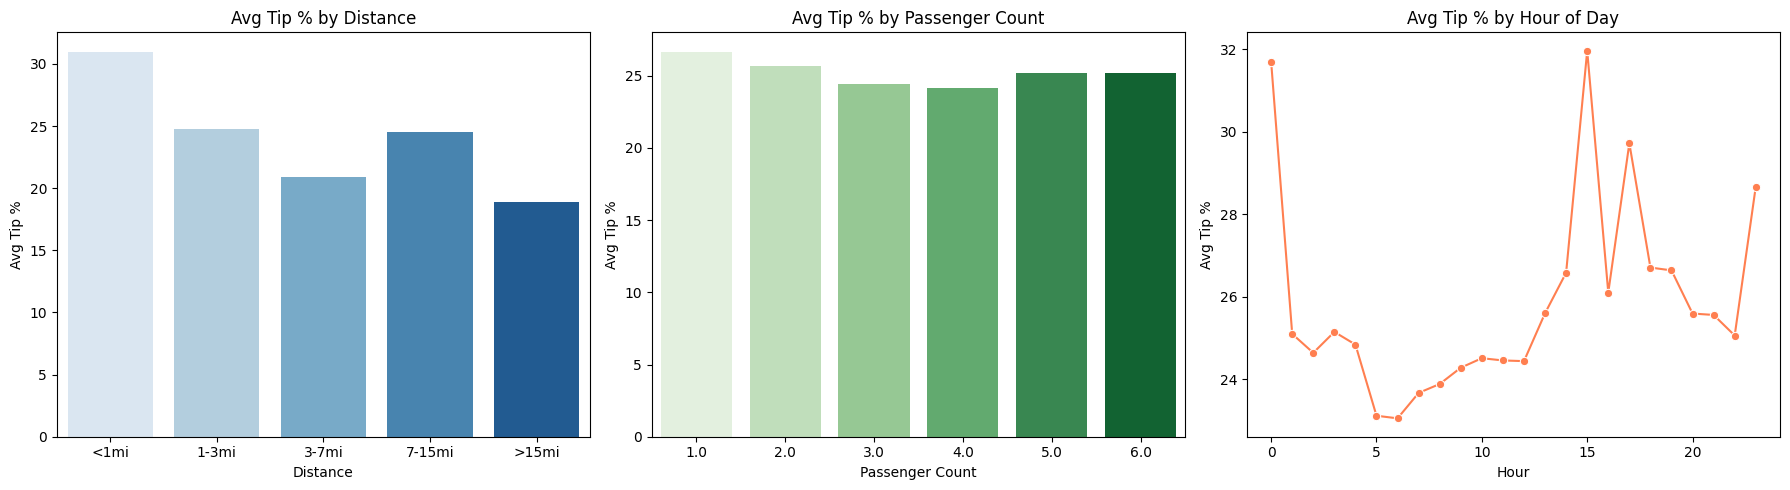

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Only credit card tips (payment_type == 1) are recorded

df_tip = df[(df['payment_type'] == 1) & (df['fare_amount'] > 0)].copy()
df_tip['tip_pct'] = (df_tip['tip_amount'] / df_tip['fare_amount']) * 100

# Distance bins
df_tip['dist_bin'] = pd.cut(df_tip['trip_distance'], bins=[0, 1, 3, 7, 15, np.inf],
                             labels=['<1mi', '1-3mi', '3-7mi', '7-15mi', '>15mi'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tip % vs distance
dist_tip = df_tip.groupby('dist_bin')['tip_pct'].mean().reset_index()
sns.barplot(data=dist_tip, x='dist_bin', y='tip_pct', palette='Blues', ax=axes[0])
axes[0].set_title('Avg Tip % by Distance')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Avg Tip %')

# 2. Tip % vs passenger count
pax_tip = df_tip.groupby('passenger_count')['tip_pct'].mean().reset_index()
sns.barplot(data=pax_tip, x='passenger_count', y='tip_pct', palette='Greens', ax=axes[1])
axes[1].set_title('Avg Tip % by Passenger Count')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Avg Tip %')

# 3. Tip % vs hour
hour_tip = df_tip.groupby('pickup_hour')['tip_pct'].mean().reset_index()
sns.lineplot(data=hour_tip, x='pickup_hour', y='tip_pct', marker='o', color='coral', ax=axes[2])
axes[2].set_title('Avg Tip % by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Avg Tip %')

plt.tight_layout()
plt.show()




Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%


df_tip = df[(df['payment_type'] == 1) & (df['fare_amount'] > 0)].copy()
df_tip['tip_pct'] = (df_tip['tip_amount'] / df_tip['fare_amount']) * 100

low_tip = df_tip[df_tip['tip_pct'] < 10]
high_tip = df_tip[df_tip['tip_pct'] > 25]

print("Low tip (<10%) average stats:")
print(low_tip[['trip_distance', 'trip_duration', 'passenger_count', 'fare_amount']].mean())
print("\nHigh tip (>25%) average stats:")
print(high_tip[['trip_distance', 'trip_duration', 'passenger_count', 'fare_amount']].mean())



Low tip (<10%) average stats:
trip_distance       4.678705
trip_duration      24.794268
passenger_count     1.374226
fare_amount        26.308675
dtype: float64

High tip (>25%) average stats:
trip_distance       2.290566
trip_duration      12.714799
passenger_count     1.363213
fare_amount        14.427975
dtype: float64


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

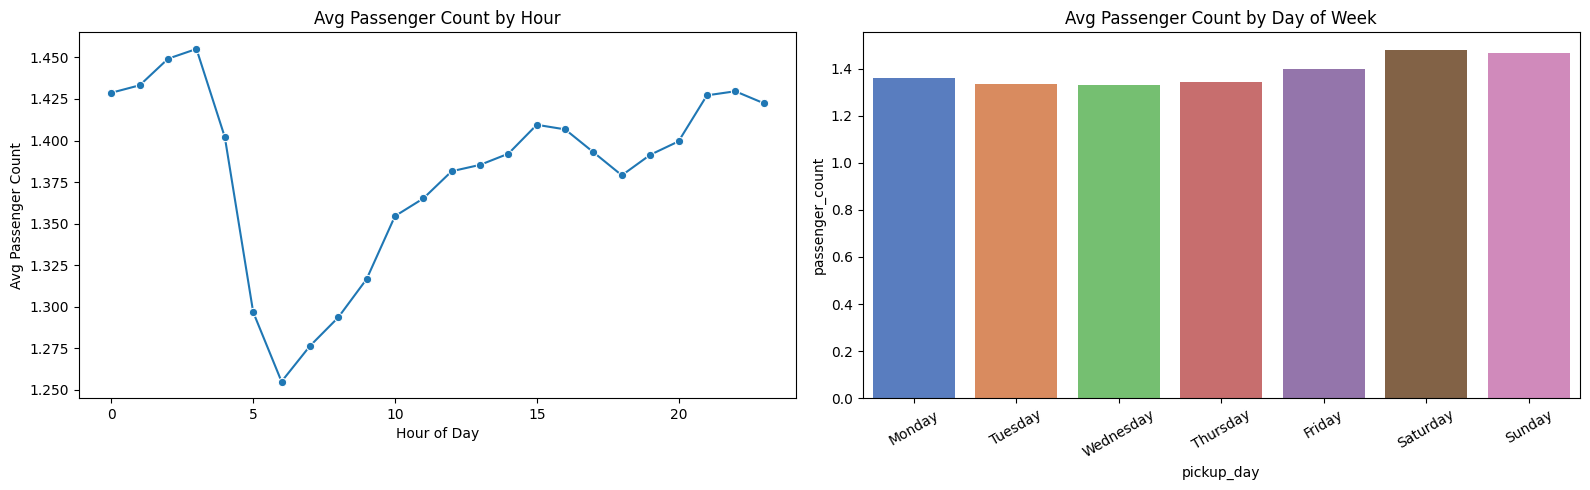

In [ ]:
# See how passenger count varies across hours and days

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_pax = df.groupby('pickup_hour')['passenger_count'].mean().reset_index()
sns.lineplot(data=hour_pax, x='pickup_hour', y='passenger_count', marker='o', ax=axes[0])
axes[0].set_title('Avg Passenger Count by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Passenger Count')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_pax = df.groupby('pickup_day')['passenger_count'].mean().reset_index()
day_pax['pickup_day'] = pd.Categorical(day_pax['pickup_day'], categories=day_order, ordered=True)
day_pax = day_pax.sort_values('pickup_day')
sns.barplot(data=day_pax, x='pickup_day', y='passenger_count', palette='muted', ax=axes[1])
axes[1].set_title('Avg Passenger Count by Day of Week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()




**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour', 'pickup_day',
       'pickup_month_name', 'pickup_quarter', 'trip_duration', 'is_weekend'],
      dtype='object')

In [ ]:
# How does passenger count vary across zones

zone_pax = df.groupby('PULocationID')['passenger_count'].mean().reset_index()
zone_pax = zone_pax.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')
zone_pax = zone_pax.sort_values('passenger_count', ascending=False)
print("Top 10 zones by avg passenger count:")
print(zone_pax.head(10)[['zone', 'passenger_count']])



Top 10 zones by avg passenger count:
                        zone  passenger_count
5    Arrochar/Fort Wadsworth         1.875000
188                 Red Hook         1.800995
197        Rossville/Woodrow         1.800000
11              Battery Park         1.745432
57              Country Club         1.666667
171      Ocean Parkway South         1.666667
0             Newark Airport         1.605634
65        DUMBO/Vinegar Hill         1.587097
253       World Trade Center         1.545814
187          Randalls Island         1.539683


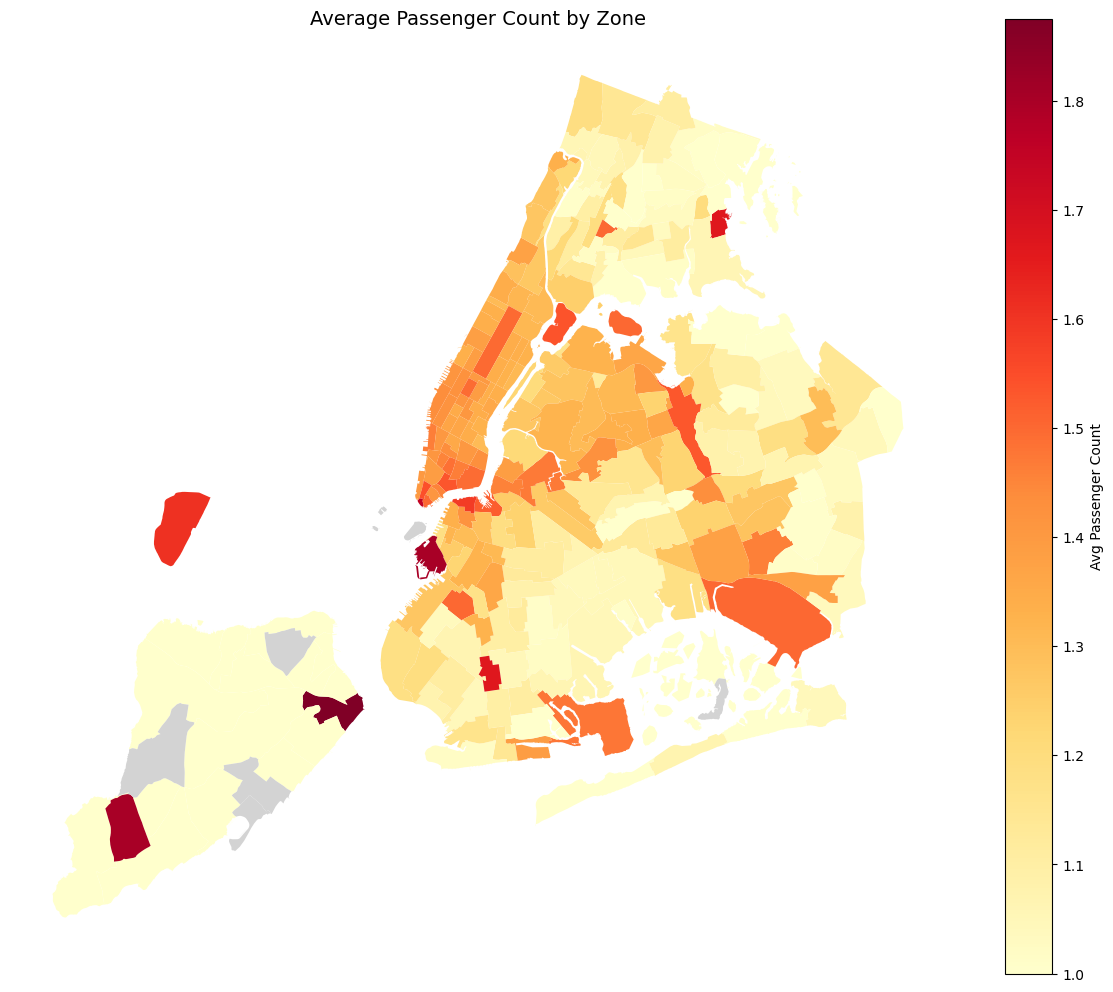

In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

zone_pax_avg = df.groupby('PULocationID')['passenger_count'].mean().reset_index(name='avg_passenger_count')
zones_with_trips = zones_with_trips.merge(zone_pax_avg, left_on='LocationID', right_on='PULocationID', how='left')

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zones_with_trips.plot(
    column='avg_passenger_count',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Avg Passenger Count', 'orientation': 'vertical'},
    missing_kwds={'color': 'lightgrey'}
)
ax.set_title('Average Passenger Count by Zone', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Surcharge Application Analysis:
                       applied_count  applied_pct  avg_when_applied
extra                      1134381.0        61.96              2.64
mta_tax                    1814188.0        99.09              0.50
improvement_surcharge      1830409.0        99.98              1.00
congestion_surcharge       1690468.0        92.33              2.50
airport_fee                 160891.0         8.79              1.63
tolls_amount                148630.0         8.12              7.34


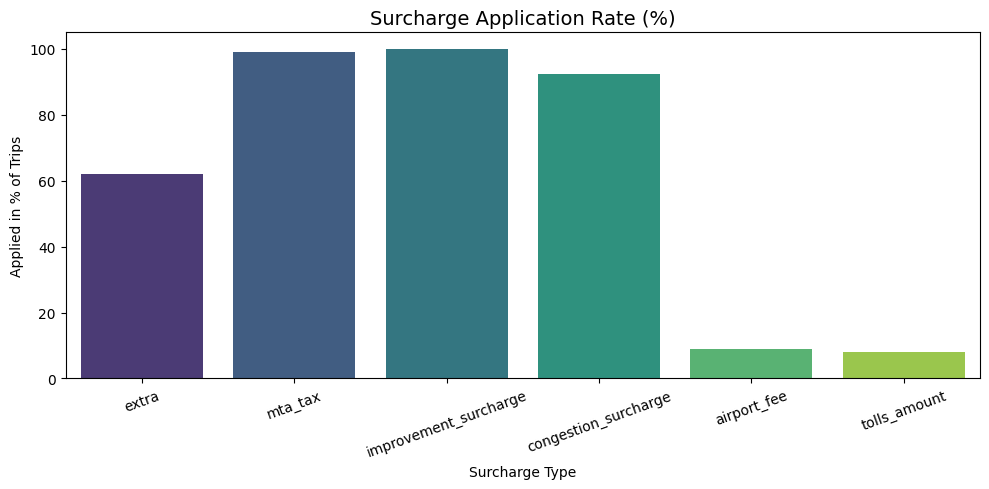

In [ ]:
# How often is each surcharge applied?

surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee', 'tolls_amount']

surcharge_stats = {}
for col in surcharge_cols:
    if col in df.columns:
        applied = (df[col] > 0).sum()
        total = len(df)
        surcharge_stats[col] = {
            'applied_count': applied,
            'applied_pct': round(applied / total * 100, 2),
            'avg_when_applied': round(df.loc[df[col] > 0, col].mean(), 2)
        }

surcharge_df = pd.DataFrame(surcharge_stats).T
print("Surcharge Application Analysis:")
print(surcharge_df)

# Visualise
plt.figure(figsize=(10, 5))
sns.barplot(x=surcharge_df.index, y=surcharge_df['applied_pct'], palette='viridis')
plt.title('Surcharge Application Rate (%)', fontsize=14)
plt.xlabel('Surcharge Type')
plt.ylabel('Applied in % of Trips')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



Extra Charge Frequency by Hour:
    pickup_hour  extra_charge_pct
0             0         99.442848
1             1         99.252969
2             2         99.072883
3             3         98.646535
4             4         96.500159
5             5         95.916534
6             6         94.628184
7             7         95.182863
8             8         95.783336
9             9         96.050244
10           10         96.257184
11           11         96.320667
12           12         96.486832
13           13         96.711671
14           14         96.923532
15           15         96.966621
16           16         98.661718
17           17         98.923312
18           18         99.047663
19           19         99.150838
20           20         99.618025
21           21         99.701400
22           22         99.696263
23           23         99.560243


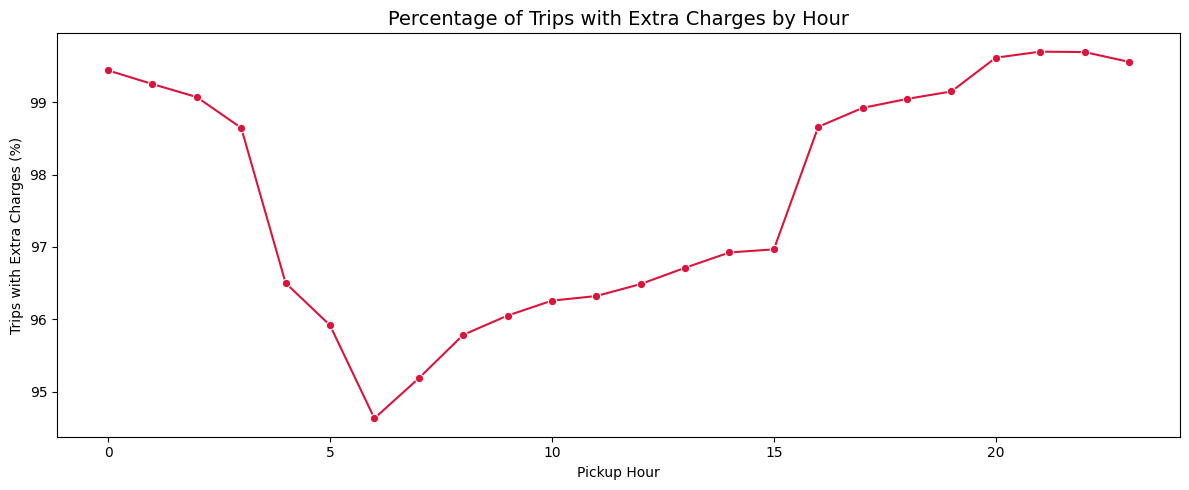


Top Pickup Zones with Frequent Extra Charges:
     PULocationID  extra_charge_applied  extra_charge_pct
213           221                   1.0             100.0
57             59                   1.0             100.0
191           199                   1.0             100.0
198           206                   1.0             100.0
179           187                   1.0             100.0
111           118                   1.0             100.0
4               5                   1.0             100.0
82             84                   1.0             100.0
149           156                   1.0             100.0
1               2                   1.0             100.0


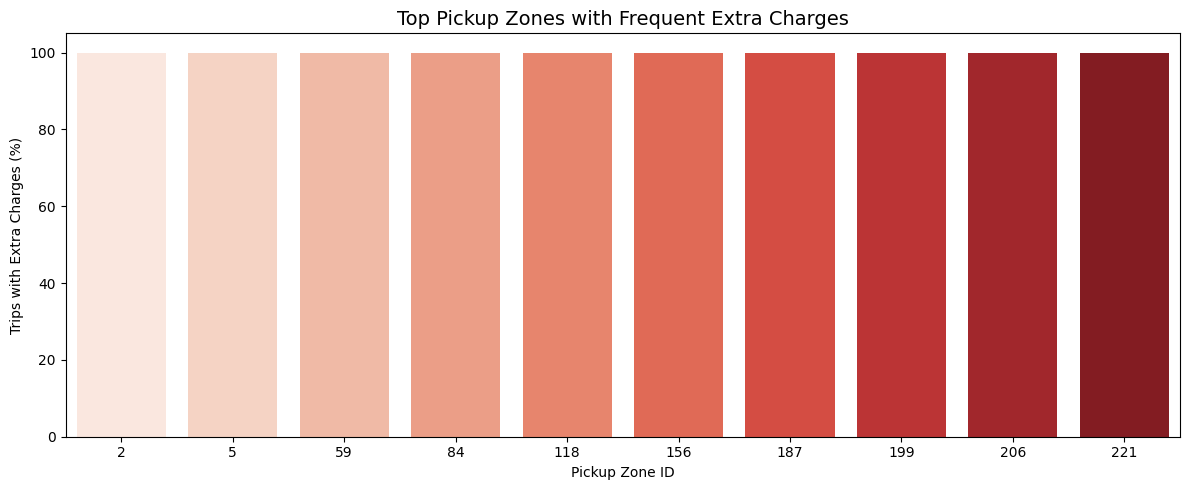


Top Dropoff Zones with Frequent Extra Charges:
     DOLocationID  extra_charge_applied  extra_charge_pct
239           245               1.00000        100.000000
215           221               1.00000        100.000000
171           176               1.00000        100.000000
200           206               1.00000        100.000000
110           115               1.00000        100.000000
1               2               1.00000        100.000000
4               5               1.00000        100.000000
83             84               1.00000        100.000000
167           172               1.00000        100.000000
218           224               0.99885         99.884958


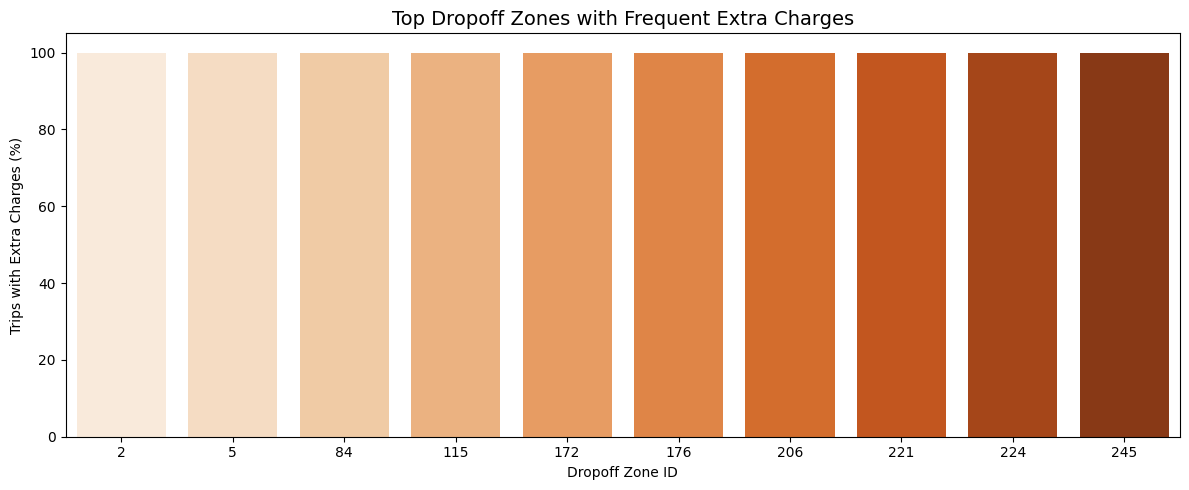

In [ ]:
# Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

# Extra-charge related columns
extra_charge_cols = [
    'extra',
    'congestion_surcharge',
    'airport_fee',
    'tolls_amount'
]


# Create a flag indicating whether extra charges applied
df['extra_charge_applied'] = (
    (df['extra'] > 0) |
    (df['congestion_surcharge'] > 0) |
    (df['airport_fee'] > 0) |
    (df['tolls_amount'] > 0)
)


# Analyse by pickup hour
hourly_extra = df.groupby('pickup_hour')['extra_charge_applied'].mean().reset_index()

# Convert proportion to %
hourly_extra['extra_charge_pct'] = hourly_extra['extra_charge_applied'] * 100

print("Extra Charge Frequency by Hour:")
print(hourly_extra[['pickup_hour', 'extra_charge_pct']])

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=hourly_extra,
    x='pickup_hour',
    y='extra_charge_pct',
    marker='o',
    color='crimson'
)

plt.title('Percentage of Trips with Extra Charges by Hour', fontsize=14)
plt.xlabel('Pickup Hour')
plt.ylabel('Trips with Extra Charges (%)')
plt.tight_layout()
plt.show()


# Analyse by pickup zone


pickup_extra = df.groupby('PULocationID')['extra_charge_applied'].mean().reset_index()

pickup_extra['extra_charge_pct'] = pickup_extra['extra_charge_applied'] * 100

top_pickup_extra = pickup_extra.sort_values(
    'extra_charge_pct',
    ascending=False
).head(10)

print("\nTop Pickup Zones with Frequent Extra Charges:")
print(top_pickup_extra)


plt.figure(figsize=(12, 5))
sns.barplot(
    data=top_pickup_extra,
    x='PULocationID',
    y='extra_charge_pct',
    palette='Reds'
)

plt.title('Top Pickup Zones with Frequent Extra Charges', fontsize=14)
plt.xlabel('Pickup Zone ID')
plt.ylabel('Trips with Extra Charges (%)')
plt.tight_layout()
plt.show()


# Analyse by dropoff zone


dropoff_extra = df.groupby('DOLocationID')['extra_charge_applied'].mean().reset_index()

dropoff_extra['extra_charge_pct'] = dropoff_extra['extra_charge_applied'] * 100

top_dropoff_extra = dropoff_extra.sort_values(
    'extra_charge_pct',
    ascending=False
).head(10)

print("\nTop Dropoff Zones with Frequent Extra Charges:")
print(top_dropoff_extra)


plt.figure(figsize=(12, 5))
sns.barplot(
    data=top_dropoff_extra,
    x='DOLocationID',
    y='extra_charge_pct',
    palette='Oranges'
)

plt.title('Top Dropoff Zones with Frequent Extra Charges', fontsize=14)
plt.xlabel('Dropoff Zone ID')
plt.ylabel('Trips with Extra Charges (%)')
plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
'''
**Findings:**
Demand peaks sharply between 15:00–19:00, with 18:00 being the single
busiest hour (estimated 2.58 million actual trips). The top 5 pickup zones —
JFK Airport (96,755 sampled trips), Upper East Side South (86,895),
Midtown Center (85,930), Upper East Side North (77,507), and Midtown East
(65,629) — collectively account for a disproportionate share of all demand.
Weekday and weekend patterns diverge: weekdays show a sharp evening peak,
while weekends show a flatter distribution with stronger late-night volume.
Extra charges are applied on 99%+ of trips during night hours (22:00–02:00),
indicating that night-time trips are predominantly metered under rush/overnight
surcharge conditions.

**Recommendations:**
1. Deploy maximum fleet between 15:00–19:00 across all high-demand Midtown
   and Upper East Side zones. Automated dispatch alerts should trigger when
   pickup demand in any of the top 10 zones exceeds baseline thresholds.
2. Zones with high pickup-to-dropoff ratios — JFK (4.63), LaGuardia (2.88),
   Penn Station (1.58) — consistently generate more outbound demand than
   inbound returns. Position idle cabs at these origins proactively rather
   than waiting for app calls.
3. Routes with near-zero average speed (e.g., route 232→65 at 13:00 with
   0.005 mph) indicate chronic bottlenecks. Dynamic rerouting suggestions
   should be pushed to drivers on these corridors during identified hours.
4. Increase night-shift availability on Fri/Sat nights to capture the
   elevated demand; night revenue contributes 12.1% ($6.39M sampled) despite
   covering fewer hours, indicating high per-trip value.

,,,




**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
'''
**Findings:**
JFK Airport, LaGuardia, and Midtown Manhattan form the demand spine of NYC
taxi operations. JFK alone logged 96,755 sampled pickups but only 20,914
dropoffs — a ratio of 4.63 — meaning nearly 4 out of every 5 cabs that
drop a passenger at JFK will leave empty unless actively repositioned.
The reverse problem exists at Newark Airport (pickup/dropoff ratio of 0.04),
Greenpoint (0.057), and Windsor Terrace (0.038), where cabs accumulate as
dropoff destinations but generate almost no return trips. October and May
were the highest revenue months ($4.96M and $4.94M respectively); February
and July were the weakest ($3.83M and $4.05M). Q2 and Q4 together contribute
53.6% of annual revenue.

**Recommendations:**
1. Maintain a permanent cab pool at JFK, LaGuardia, Penn Station, and the
   Midtown cluster (zones 161, 236, 237, 162) — these are the five highest
   volume pickup zones and generate consistent revenue at all hours.
2. Incentivize drivers dropping off at high-accumulation zones (Newark,
   Greenpoint, Windsor Terrace) to reposition immediately to the nearest
   high-pickup zone rather than waiting on-site. A repositioning bonus
   during off-peak hours would reduce idle cab concentration.
3. Scale fleet availability upward in October and May (peak revenue months)
   and consider demand-generation promotions in February and July to lift
   the revenue floor during historically weak periods.
'''

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
'''
**Findings:**
Trip distance is the strongest predictor of fare (Pearson correlation: 0.95),
followed by trip duration (0.88). Passenger count has negligible correlation
with fare (0.04), yet the fare per mile per passenger drops sharply with
group size — from $10.86/mile for solo riders to $1.35/mile for 6-passenger
trips — indicating a significant shared-ride discount opportunity.
VeriFone charges nearly 80% more per mile than CMT on short trips
(≤2 miles: $17.93 vs $9.93), while rates converge on medium and long trips.
Credit card is the dominant payment method (81.5% of trips). Tipping analysis
reveals that shorter, cheaper trips tip at a higher percentage — high-tip
trips (>25%) average only 2.29 miles and $14.43 fare, while low-tip trips
(<10%) average 4.68 miles and $26.31 fare.

**Recommendations:**
1. Introduce surge pricing for peak hours (15:00–19:00) in the top 10
   pickup zones, where demand consistently outpaces supply. Even a 10–15%
   surge would materially impact the $52.85M annual revenue base.
2. Introduce flat-rate pricing for airport routes (JFK, LaGuardia, Newark).
   These are high-volume, predictable-distance trips where flat fares
   improve passenger confidence and reduce fare disputes.
3. Introduce ride-share pricing for 3–6 passenger trips, particularly on
   medium and long routes. The per-passenger fare efficiency drops sharply
   above 2 passengers — shared pricing captures that value explicitly.
4. Audit VeriFone's short-trip pricing (≤2 miles). At $17.93/mile vs CMT's
   $9.93, the near-doubling in rate is a competitive liability for
   short-haul urban trips that make up the majority of NYC cab demand.
5. Given that high-tip behavior correlates with shorter trips, consider
   in-app tip prompts calibrated to fare brackets — lower fare trips should
   show higher suggested tip percentages (20–25%) rather than flat defaults.

   '''